### Importing libraries and Data

In [2]:
## Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [3]:
# Import data

caract = pd.read_csv("C:/Project/DATA/caracteristics.csv", encoding="latin-1", low_memory=False)
holidays = pd.read_csv("C:/Project/DATA/holidays.csv", encoding="latin-1")
places = pd.read_csv("C:/Project/DATA/places.csv", encoding="latin-1", low_memory=False)
users = pd.read_csv("C:/Project/DATA/users.csv", encoding="latin-1")
vehicles = pd.read_csv("C:/Project/DATA/vehicles.csv", encoding="latin-1")

In [4]:
#data introduction

print("\nCharacteristics head:")
display(caract.head())

print("\nPlaces head:")
display(places.head())

print("\nVehicles head:")
display(vehicles.head())

print("\nUsers head:")
display(users.head())

print("\nHolidays head:")
display(holidays.head())



Characteristics head:


,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,com,adr,gps,lat,long,dep
0,201600000001,16,2,1,1445,1,2,1,8.0,3.0,5.0,"46, rue Sonneville",M,0.0,0,590
1,201600000002,16,3,16,1800,1,2,6,1.0,6.0,5.0,1a rue du cimetière,M,0.0,0,590
2,201600000003,16,7,13,1900,1,1,1,1.0,6.0,11.0,NaN,M,0.0,0,590
3,201600000004,16,8,15,1930,2,2,1,7.0,3.0,477.0,52 rue victor hugo,M,0.0,0,590
4,201600000005,16,12,23,1100,1,2,3,1.0,3.0,11.0,rue Joliot curie,M,0.0,0,590



Places head:


,Num_Acc,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1
0,201600000001,3.0,39,NaN,NaN,2.0,0.0,NaN,NaN,0.0,1.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0
1,201600000002,3.0,39,NaN,NaN,1.0,0.0,NaN,NaN,0.0,1.0,2.0,0.0,58.0,1.0,0.0,1.0,0.0
2,201600000003,3.0,1,NaN,NaN,2.0,2.0,NaN,NaN,0.0,1.0,3.0,0.0,68.0,2.0,0.0,3.0,99.0
3,201600000004,4.0,0,NaN,NaN,2.0,0.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,99.0
4,201600000005,4.0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0



Vehicles head:


,Num_Acc,senc,catv,occutc,obs,obsm,choc,manv,num_veh
0,201600000001,0.0,7,0,0.0,0.0,1.0,1.0,B02
1,201600000001,0.0,2,0,0.0,0.0,7.0,15.0,A01
2,201600000002,0.0,7,0,6.0,0.0,1.0,1.0,A01
3,201600000003,0.0,7,0,0.0,1.0,6.0,1.0,A01
4,201600000004,0.0,32,0,0.0,0.0,1.0,1.0,B02



Users head:


,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201600000001,1.0,1,1,2,0.0,11.0,0.0,0.0,0.0,1983.0,B02
1,201600000001,1.0,1,3,1,9.0,21.0,0.0,0.0,0.0,2001.0,A01
2,201600000002,1.0,1,3,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01
3,201600000002,2.0,2,3,1,0.0,11.0,0.0,0.0,0.0,2000.0,A01
4,201600000002,3.0,2,3,2,0.0,11.0,0.0,0.0,0.0,1962.0,A01



Holidays head:


,ds,holiday
0,2005-01-01,New year
1,2005-03-28,Easter Monday
2,2005-05-01,Labour Day
3,2005-05-05,Ascension Thursday
4,2005-05-08,Victory in Europe Day


### CARACT (Characteristics) Dataframe - Auditing, Cleaning and Preprocessing

In [5]:
#column renaming

caract = caract.rename(columns={
    "Num_Acc":"accident_id",
    "jour":"day",
    "mois":"month",
    "an":"year",
    "hrmn":"hourminute",
    "lum":"lighting",
    "dep":"department",
    "com" : "commune_code",
    "agg":"urban_area",
    "int" : "intersection",
    "atm":"weather",
    "col":"collision_type",
    "adr" :"address",
    "lat":"latitude",
    "long":"longitude"
})
caract.head()

,accident_id,year,month,day,hourminute,lighting,urban_area,intersection,weather,collision_type,commune_code,address,gps,latitude,longitude,department
0,201600000001,16,2,1,1445,1,2,1,8.0,3.0,5.0,"46, rue Sonneville",M,0.0,0,590
1,201600000002,16,3,16,1800,1,2,6,1.0,6.0,5.0,1a rue du cimetière,M,0.0,0,590
2,201600000003,16,7,13,1900,1,1,1,1.0,6.0,11.0,NaN,M,0.0,0,590
3,201600000004,16,8,15,1930,2,2,1,7.0,3.0,477.0,52 rue victor hugo,M,0.0,0,590
4,201600000005,16,12,23,1100,1,2,3,1.0,3.0,11.0,rue Joliot curie,M,0.0,0,590


In [6]:
# Auditing

# 1: quick overview
print("shape:", caract.shape)
print("\ndtypes (all):\n", caract.dtypes)
print("\nhead(5):\n", caract.head(5))
print("\ninfo():")
caract.info()

# 2: missingness summary (top 30)
miss = caract.isna().sum().sort_values(ascending=False)
print(miss.head(30))

# 3: unique counts for carcteristics columns (small preview)
cols_check = ['accident_id', 'year', 'month', 'day', 'hourminute', 'lighting',
       'urban_area', 'intersection', 'weather', 'collision_type',
       'commune_code', 'address', 'gps', 'latitude', 'longitude',
       'department']
for c in cols_check:
    if c in caract.columns:
        print(f"\n{c} -- n_unique:", caract[c].nunique(dropna=True))
        print("value_sample:", caract[c].dropna().sort_values().unique()[:12])

# 4: primary key duplicates
n_unique = caract["accident_id"].nunique()
print("\n Accident_id rows:", len(caract), "unique Accident_id:", n_unique, "duplicates:", len(caract)-n_unique)

shape: (839985, 16)

dtypes (all):
 accident_id         int64
year                int64
month               int64
day                 int64
hourminute          int64
lighting            int64
urban_area          int64
intersection        int64
weather           float64
collision_type    float64
commune_code      float64
address            object
gps                object
latitude          float64
longitude          object
department          int64
dtype: object

head(5):
     accident_id  year  month  day  hourminute  lighting  urban_area  \
0  201600000001    16      2    1        1445         1           2   
1  201600000002    16      3   16        1800         1           2   
2  201600000003    16      7   13        1900         1           1   
3  201600000004    16      8   15        1930         2           2   
4  201600000005    16     12   23        1100         1           2   

   intersection  weather  collision_type  commune_code              address  \
0             1  

In [7]:
# -- Mapping dictionaries --
lighting_map = {
    1: "Daylight",
    2: "Twilight_or_dawn",
    3: "Night_without_public_lighting",
    4: "Night_with_public_lighting_not_functioning",
    5: "Night_with_public_lighting_on",
}

urban_map = {
    1: "Out_of_agglomeration",
    2: "Built_up_area"
}

intersection_map = {
    0: "Unknown",
    1: "Out_of_intersection",
    2: "Intersection_X",
    3: "Intersection_T",
    4: "Intersection_Y",
    5: ">4_branches",
    6: "Roundabout",
    7: "Place",
    8: "Level_crossing",
    9: "Other"
}

weather_map = {
    1: "Normal",
    2: "Light_rain",
    3: "Heavy_rain",
    4: "Snow_or_hail",
    5: "Fog_or_smoke",
    6: "Strong_wind_or_storm",
    7: "Dazzling",
    8: "Cloudy",
    9: "Other"
}

collision_map = {
    1: "Frontal_two_vehicles",
    2: "Rear_end_two_vehicles",
    3: "Side_two_vehicles",
    4: "Chain_three_plus",
    5: "Multiple_three_plus",
    6: "Other_collision",
    7: "No_collision",
}

gps_map = {
    "M": "Manual_entry",
    "A": "Automatic_device",
    "G": "GPS",
    "R": "Road_reference",
    "Y": "Survey",
    "S": "Satellite",
    "T": "Topographic",
    "C": "Cartographic",
    "P": "Photogrammetric",
    "0": "No_geolocation"
}


# Apply maps safely (only for existing columns)
if "lighting" in caract.columns:
    caract["lighting_label"] = caract["lighting"].map(lighting_map).fillna("Unknown")
if "urban_area" in caract.columns:
    caract["urban_label"] = caract["urban_area"].map(urban_map).fillna("Unknown")
if "intersection" in caract.columns:
    caract["intersection_label"] = caract["intersection"].map(intersection_map).fillna("Unknown")
if "weather" in caract.columns:
    caract["weather_label"] = caract["weather"].map(weather_map)
if "collision_type" in caract.columns:
    caract["collision_label"] = caract["collision_type"].map(collision_map)
if "gps" in caract.columns:
    caract["gps_label"] = caract["gps"].map(gps_map).fillna("Unknown").astype("category")


In [8]:
#latitude and longitude

# 1) Clean raw columns robustly
caract["longitude"] = ( caract["longitude"].astype(str).str.strip().str.replace(",", ".", regex=False))

caract["latitude"] = ( caract["latitude"].astype(str).str.strip().str.replace(",", ".", regex=False))

# 2) Coerce to numeric
caract["longitude"] = pd.to_numeric(caract["longitude"], errors="coerce")
caract["latitude"] = pd.to_numeric(caract["latitude"], errors="coerce")

# 3) Set placeholders to NaN
caract.loc[caract["longitude"] == 0, "longitude"] = pd.NA
caract.loc[caract["latitude"] == 0, "latitude"] = pd.NA

# 4) Generate candidates for normalization
lon_raw = caract["longitude"]
lat_raw = caract["latitude"]

lon_cand = pd.DataFrame({
    "raw": lon_raw,
    "div1e5": lon_raw / 100000,  # common scale in this dataset
    "div1e6": lon_raw / 1000000  # fallback if some rows use 1e6
})

lat_cand = pd.DataFrame({
    "raw": lat_raw,
    "div1e5": lat_raw / 100000,
    "div1e6": lat_raw / 1000000
})

# 5) Choose candidate that falls in valid France ranges
def choose_lon(row):
    for v in [row["raw"], row["div1e5"], row["div1e6"]]:
        if pd.notna(v) and -10 <= v <= 10:
            return v
    return pd.NA

def choose_lat(row):
    for v in [row["raw"], row["div1e5"], row["div1e6"]]:
        if pd.notna(v) and 40 <= v <= 52:
            return v
    return pd.NA

caract["longitude_num"] = lon_cand.apply(choose_lon, axis=1)
caract["latitude_num"]  = lat_cand.apply(choose_lat, axis=1)

# 6) Basic validation
print("Longitude range:", caract["longitude_num"].min(), caract["longitude_num"].max())
print("Negative longitudes:", (caract["longitude_num"] < 0).sum())
print("Latitude range:", caract["latitude_num"].min(), caract["latitude_num"].max())

# 7) Quick sanity sample
print(caract[["latitude","longitude","latitude_num","longitude_num"]].head(10))

print("Latitude range:", caract["latitude_num"].min(), caract["latitude_num"].max())
print("Longitude range:", caract["longitude_num"].min(), caract["longitude_num"].max())

print("Missing latitudes:", caract["latitude_num"].isna().sum())
print("Missing longitudes:", caract["longitude_num"].isna().sum())

outliers = caract[
    (caract["latitude_num"] < 41) | (caract["latitude_num"] > 52) |
    (caract["longitude_num"] < -5) | (caract["longitude_num"] > 10)
]
print("Outlier rows:", len(outliers))

print("Negative longitudes:", (caract["longitude_num"] < 0).sum())

Longitude range: -5.246 9.8
Negative longitudes: 48942
Latitude range: 41.23455 51.21
   latitude  longitude latitude_num longitude_num
0       NaN        NaN         <NA>          <NA>
1       NaN        NaN         <NA>          <NA>
2       NaN        NaN         <NA>          <NA>
3       NaN        NaN         <NA>          <NA>
4       NaN        NaN         <NA>          <NA>
5       NaN        NaN         <NA>          <NA>
6       NaN        NaN         <NA>          <NA>
7       NaN        NaN         <NA>          <NA>
8       NaN        NaN         <NA>          <NA>
9       NaN        NaN         <NA>          <NA>
Latitude range: 41.23455 51.21
Longitude range: -5.246 9.8
Missing latitudes: 619303
Missing longitudes: 618386
Outlier rows: 2
Negative longitudes: 48942


In [9]:
# valid geo
caract["valid_geo"] = (
    caract["latitude_num"].between(41, 52, inclusive="both") &
    caract["longitude_num"].between(-5, 10, inclusive="both")
)

# Quick check
print(caract["valid_geo"].value_counts())
print("Valid lat range:", caract.loc[caract["valid_geo"], "latitude_num"].min(),
      caract.loc[caract["valid_geo"], "latitude_num"].max())
print("Valid lon range:", caract.loc[caract["valid_geo"], "longitude_num"].min(),
      caract.loc[caract["valid_geo"], "longitude_num"].max())

valid_geo
False    619392
True     220593
Name: count, dtype: int64
Valid lat range: 41.23455 51.21
Valid lon range: -4.793 9.8


In [10]:
# year_month_day_date (expanding 2-digit years safely and build date)

caract["year"] = pd.to_numeric(caract["year"], errors="coerce")
def expand_year(x):
    if pd.isna(x): return pd.NA
    x = int(x)
    return 2000 + x if x < 100 else x

caract["year"] = pd.to_numeric(caract["year"], errors="coerce").apply(expand_year).astype("Int64")
caract["month"] = pd.to_numeric(caract["month"], errors="coerce").astype("Int64")
caract["day"] = pd.to_numeric(caract["day"], errors="coerce").astype("Int64")
caract["date"] = pd.to_datetime(dict(year=caract["year"], month=caract["month"], day=caract["day"]), errors="coerce")

# quick check
print("dates valid:", caract["date"].notna().sum(), "/", len(caract))


dates valid: 839985 / 839985


In [11]:
# parse hourminute into hour/minute/time_hhmm 

def parse_hourminute(x):
        try:
            if pd.isna(x): return pd.NA, pd.NA
            s = str(int(x)).zfill(4) if str(x).strip().isdigit() else "".join(ch for ch in str(x) if ch.isdigit()).zfill(4)
            if not s: return pd.NA, pd.NA
            h, m = int(s[:2]), int(s[2:])
            return (h, m) if 0 <= h <= 23 and 0 <= m <= 59 else (pd.NA, pd.NA)
        except:
            return pd.NA, pd.NA

if "hour" not in caract.columns or "minute" not in caract.columns:  
    hm = caract["hourminute"].apply(parse_hourminute)
    caract["hour"] = hm.apply(lambda t: t[0])
    caract["minute"] = hm.apply(lambda t: t[1])
    caract["time_hhmm"] = caract.apply(lambda r: f"{int(r['hour']):02d}:{int(r['minute']):02d}" 
                               if pd.notna(r['hour']) and pd.notna(r['minute']) else pd.NA, axis=1)

print("hour non-null:", caract["hour"].notna().sum())

hour non-null: 839985


In [12]:
# time_of_day: based on hour
def get_time_of_day(h):
    if pd.isna(h): return pd.NA
    if 5 <= h < 12: return "Morning"
    elif 12 <= h < 17: return "Afternoon"
    elif 17 <= h < 21: return "Evening"
    else: return "Night"

caract["time_of_day"] = caract["hour"].apply(get_time_of_day).astype("category")

In [13]:
# is_weekend: Saturday (5) or Sunday (6)
caract["is_weekend"] = caract["date"].dt.dayofweek.isin([5,6])

In [14]:
# season: based on month
def get_season(m):
    if pd.isna(m): return pd.NA
    if m in [12,1,2]: return "Winter"
    elif m in [3,4,5]: return "Spring"
    elif m in [6,7,8]: return "Summer"
    else: return "Autumn"

caract["season"] = caract["month"].apply(get_season).astype("category")

In [15]:
# unified dtype conversion applied directly to caract

# accident_id stays int64
caract["accident_id"] = caract["accident_id"].astype("int64")

# numeric codes (nullable int)
int_cols = ["year","month","day","hourminute","lighting","urban_area",
            "intersection","department","hour","minute","commune_code"]
for c in int_cols:
    if c in caract.columns:
        caract[c] = pd.to_numeric(caract[c], errors="coerce").astype("Int64")

# continuous numeric
float_cols = ["weather","collision_type","latitude","longitude","latitude_num","longitude_num"]
for c in float_cols:
    if c in caract.columns:
        caract[c] = pd.to_numeric(caract[c], errors="coerce").astype("float64")

# categorical labels
cat_cols = ["lighting_label","urban_label","intersection_label",
            "weather_label","collision_label","gps_label","time_of_day","season"]
for c in cat_cols:
    if c in caract.columns:
        caract[c] = caract[c].astype("category")

# text fields
text_cols = ["address","gps","time_hhmm"]
for c in text_cols:
    if c in caract.columns:
        caract[c] = caract[c].astype(str)

# datetime
if "date" in caract.columns:
    caract["date"] = pd.to_datetime(caract["date"], errors="coerce")

# boolean flags
bool_cols = ["valid_geo","is_weekend"]
for c in bool_cols:
    if c in caract.columns:
        caract[c] = caract[c].astype("bool")

# quick summary
print("\nDtypes after conversion:\n", caract.dtypes)
print("\nMissing values per column (top 10):\n", caract.isna().sum().sort_values(ascending=False).head(10))


Dtypes after conversion:
 accident_id                    int64
year                           Int64
month                          Int64
day                            Int64
hourminute                     Int64
lighting                       Int64
urban_area                     Int64
intersection                   Int64
weather                      float64
collision_type               float64
commune_code                   Int64
address                       object
gps                           object
latitude                     float64
longitude                    float64
department                     Int64
lighting_label              category
urban_label                 category
intersection_label          category
weather_label               category
collision_label             category
gps_label                   category
longitude_num                float64
latitude_num                 float64
valid_geo                       bool
date                  datetime64[ns]
hour       

In [16]:
# === Final cleaning checks for caract ===

print("=== Schema (dtypes) ===")
print(caract.dtypes)

print("\n=== Shape ===")
print("Rows:", caract.shape[0], "| Columns:", caract.shape[1])

print("\n=== Missing values (top 15) ===")
print(caract.isna().sum().sort_values(ascending=False).head(15))

print("\n=== Duplicate check ===")
dup_count = caract["accident_id"].duplicated().sum()
print("Duplicate accident_id count:", dup_count)


print("\n=== Category checks ===")
for c in ["lighting_label","urban_label","intersection_label",
          "weather_label","collision_label","gps_label",
          "time_of_day","season"]:
    if c in caract.columns:
        print(f"{c}: {caract[c].nunique(dropna=True)} categories")

print("\n=== Sample derived features ===")
print(caract[["date","hour","time_of_day","is_weekend","season"]].head(10))

=== Schema (dtypes) ===
accident_id                    int64
year                           Int64
month                          Int64
day                            Int64
hourminute                     Int64
lighting                       Int64
urban_area                     Int64
intersection                   Int64
weather                      float64
collision_type               float64
commune_code                   Int64
address                       object
gps                           object
latitude                     float64
longitude                    float64
department                     Int64
lighting_label              category
urban_label                 category
intersection_label          category
weather_label               category
collision_label             category
gps_label                   category
longitude_num                float64
latitude_num                 float64
valid_geo                       bool
date                  datetime64[ns]
hour          

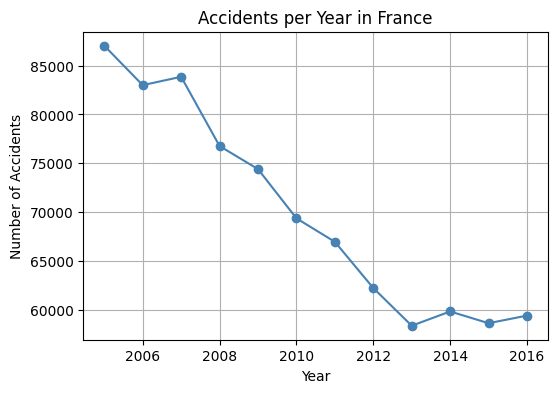

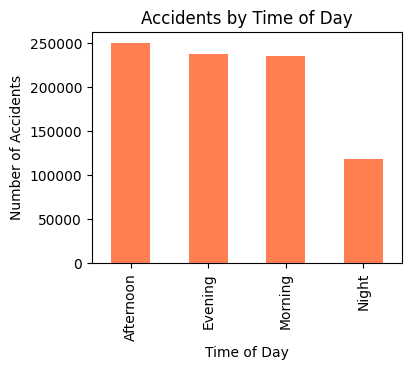

<Figure size 1000x1000 with 0 Axes>

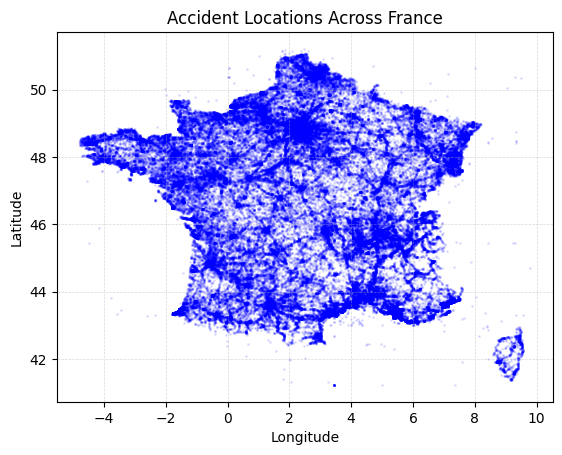

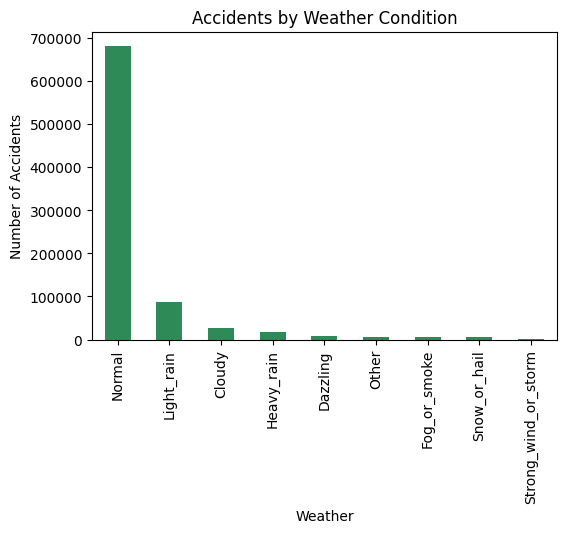

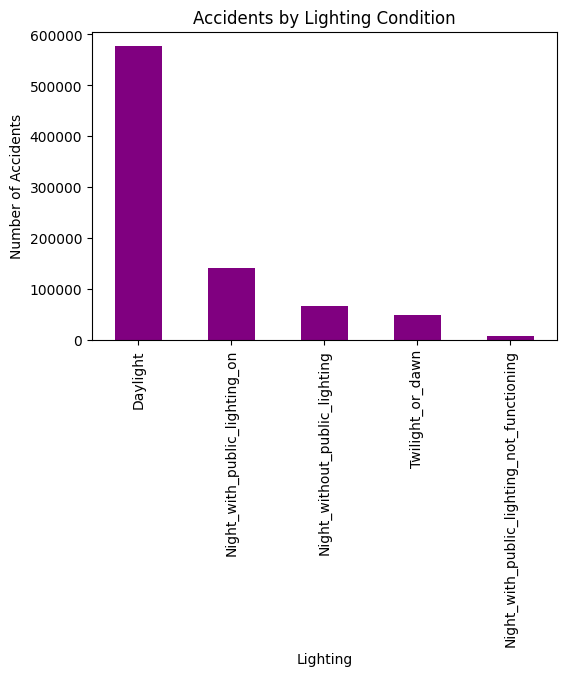

In [17]:
### some visualization plots

#1
# Accidents per Year (Line Plot)
#This shows long‑term accident trends across 2005–2016.

import matplotlib.pyplot as plt

# Group by year and count accidents
accidents_per_year = caract.groupby("year").size()

# Plot
plt.figure(figsize=(6,4))
accidents_per_year.plot(kind="line", marker="o", color="steelblue")
plt.title("Accidents per Year in France")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.show()

# a decline over time, reflecting road safety improvements.

#2
# Accidents by Time of Day (Bar Chart)
# This highlights daily risk patterns

accidents_timeofday = caract["time_of_day"].value_counts()

plt.figure(figsize=(4,3))
accidents_timeofday.plot(kind="bar", color="coral")
plt.title("Accidents by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.show()

# Evening and Afternoon peaks (rush hour)

#3
# Spatial Distribution (Scatter Plot)
# This confirms clustering inside France

plt.figure(figsize=(10,10))
caract[caract["valid_geo"]].plot.scatter(x="longitude_num", y="latitude_num", alpha=0.1, s=1, color="blue")

plt.title("Accident Locations Across France")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.show()

# It shows dense clusters around Paris, Lyon, Marseille, Lille

#4
# Accidents by Weather or Lighting (Bar Chart)
# This shows environmental influence

plt.figure(figsize=(6,4))
caract["weather_label"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")
plt.show()

plt.figure(figsize=(6,4))
caract["lighting_label"].value_counts().plot(kind="bar", color="purple")
plt.title("Accidents by Lighting Condition")
plt.xlabel("Lighting")
plt.ylabel("Number of Accidents")
plt.show()


# It shows clear weather and daylight to dominate, but night/fog accidents are disproportionately severe.


In [18]:
caract.columns

Index(['accident_id', 'year', 'month', 'day', 'hourminute', 'lighting',
       'urban_area', 'intersection', 'weather', 'collision_type',
       'commune_code', 'address', 'gps', 'latitude', 'longitude', 'department',
       'lighting_label', 'urban_label', 'intersection_label', 'weather_label',
       'collision_label', 'gps_label', 'longitude_num', 'latitude_num',
       'valid_geo', 'date', 'hour', 'minute', 'time_hhmm', 'time_of_day',
       'is_weekend', 'season'],
      dtype='object')

In [19]:
### Cleaning CARACT by Dropping columns before merging in master dataframe for visualisation

drop_cols_caract = [
    "hourminute", "lighting", "urban_area", "intersection", "weather", "collision_type","commune_code",
    "address", "gps", "latitude", "longitude", "department"
]

caract = caract.drop(columns=[c for c in drop_cols_caract if c in caract.columns])

print("Post-drop shape:", caract.shape)
print("Remaining columns:", caract.columns.tolist())


Post-drop shape: (839985, 20)
Remaining columns: ['accident_id', 'year', 'month', 'day', 'lighting_label', 'urban_label', 'intersection_label', 'weather_label', 'collision_label', 'gps_label', 'longitude_num', 'latitude_num', 'valid_geo', 'date', 'hour', 'minute', 'time_hhmm', 'time_of_day', 'is_weekend', 'season']


### PLACES Dataframe - Auditing, Cleaning and Preprocessing

In [20]:
# Inspect places dataframe
print("Columns:", list(places.columns))

print("\nDtypes:")
print(places.dtypes)

print("\nTop missing (up to 10):")
print(places.isna().sum().sort_values(ascending=False).head(10))

print("\nShape:", places.shape)

print("\nSample (first 5 rows):")
display(places.head(5))

Columns: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'pr', 'pr1', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'env1']

Dtypes:
Num_Acc      int64
catr       float64
voie        object
v1         float64
v2          object
circ       float64
nbv        float64
pr         float64
pr1        float64
vosp       float64
prof       float64
plan       float64
lartpc     float64
larrout    float64
surf       float64
infra      float64
situ       float64
env1       float64
dtype: object

Top missing (up to 10):
v2         806032
v1         507169
pr1        426522
pr         425215
voie        59071
lartpc       9545
larrout      8279
nbv          1790
vosp         1640
infra        1278
dtype: int64

Shape: (839985, 18)

Sample (first 5 rows):


,Num_Acc,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1
0,201600000001,3.0,39,NaN,NaN,2.0,0.0,NaN,NaN,0.0,1.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0
1,201600000002,3.0,39,NaN,NaN,1.0,0.0,NaN,NaN,0.0,1.0,2.0,0.0,58.0,1.0,0.0,1.0,0.0
2,201600000003,3.0,1,NaN,NaN,2.0,2.0,NaN,NaN,0.0,1.0,3.0,0.0,68.0,2.0,0.0,3.0,99.0
3,201600000004,4.0,0,NaN,NaN,2.0,0.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,99.0
4,201600000005,4.0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0


In [21]:
places = places.rename(columns={
    "Num_Acc": "accident_id",
    "catr": "road_category",
    "voie": "road_number",
    "v1": "road_number_index",
    "v2": "road_number_suffix",
    "circ": "traffic_regime",
    "nbv": "num_lanes",
    "pr": "milestone",
    "pr1": "milestone_distance",
    "vosp": "reserved_lane",
    "prof": "road_profile",
    "plan": "road_layout",
    "lartpc": "pedestrian_crossing_width",
    "larrout": "road_width",
    "surf": "surface_condition",
    "infra": "infrastructure",
    "situ": "situation",
    "env1": "school_zone"
})

In [22]:
# Auditing

# 1: quick overview
print("shape:", places.shape)
print("\ndtypes (all):\n", places.dtypes)
print("\nhead(5):\n", places.head(5))
print("\ninfo():")
places.info()

# 2: missingness summary (top 30)
miss = places.isna().sum().sort_values(ascending=False)
print(miss.head(30))

# 3: unique counts for mapping
for c in places.columns:
    if c in places.columns:
        print(f"\n{c} -- n_unique:", places[c].nunique(dropna=True))
        print("value_sample:", places[c].dropna().sort_values().unique()[:10])

# 4: primary key duplicates
n_unique = caract["accident_id"].nunique()
print("\n Accident_id rows:", len(caract), "unique Accident_id:", n_unique, "duplicates:", len(caract)-n_unique)

shape: (839985, 18)

dtypes (all):
 accident_id                    int64
road_category                float64
road_number                   object
road_number_index            float64
road_number_suffix            object
traffic_regime               float64
num_lanes                    float64
milestone                    float64
milestone_distance           float64
reserved_lane                float64
road_profile                 float64
road_layout                  float64
pedestrian_crossing_width    float64
road_width                   float64
surface_condition            float64
infrastructure               float64
situation                    float64
school_zone                  float64
dtype: object

head(5):
     accident_id  road_category road_number  road_number_index  \
0  201600000001            3.0          39                NaN   
1  201600000002            3.0          39                NaN   
2  201600000003            3.0           1                NaN   
3  2016000000

In [23]:
#mapping

road_category_map = {
    1: "Highway",
    2: "National_road",
    3: "Departmental_road",
    4: "Communal_way",
    5: "Off_public_network",
    6: "Parking_lot",
    9: "other"
}

traffic_regime_map = {
    0: "Unknown",
    1: "One_way",
    2: "Bidirectional",
    3: "Separated_carriageways",
    4: "Variable_assignment"
}

reserved_lane_map = {
    0: "Unknown",
    1: "Bike_path",
    2: "Cycle_bank",
    3: "Reserved_channel"
}

road_profile_map = {
    0: "Unknown",
    1: "Flat",
    2: "Slope",
    3: "Hilltop",
    4: "Hill_bottom"
}

road_layout_map = {
    0: "Unknown",
    1: "Straight",
    2: "Curve_left",
    3: "Curve_right",
    4: "S-bend"
}

surface_condition_map = {
    0: "Unknown",
    1: "Normal",
    2: "Wet",
    3: "Puddles",
    4: "Flooded",
    5: "Snow",
    6: "Mud",
    7: "Icy",
    8: "Oil",
    9: "Other"
}

infrastructure_map = {
    0: "Unknown",
    1: "Tunnel",
    2: "Bridge",
    3: "Interchange",
    4: "Railway",
    5: "Roundabout",
    6: "Pedestrian_area",
    7: "Tollzone"
}

situation_map = {
    0: "Unknown",
    1: "On_road",
    2: "On_emergency_stop_band",
    3: "On_verge",
    4: "On_sidewalk",
    5: "On_bike_path"
}

school_zone_map = {
    0: "Not_near_school",
    3: "Near_school",
    99: "Unknown"
}

# --- Applying mappings ---
places["road_category_label"] = places["road_category"].map(road_category_map)
places["traffic_regime_label"] = places["traffic_regime"].map(traffic_regime_map)
places["reserved_lane_label"] = places["reserved_lane"].map(reserved_lane_map)
places["road_profile_label"] = places["road_profile"].map(road_profile_map)
places["road_layout_label"] = places["road_layout"].map(road_layout_map)
places["surface_condition_label"] = places["surface_condition"].map(surface_condition_map)
places["infrastructure_label"] = places["infrastructure"].map(infrastructure_map)
places["situation_label"] = places["situation"].map(situation_map)
places["school_zone_label"] = places["school_zone"].map(school_zone_map)

# --- Filling NaNs with "Unknown" ---
for col in [
    "road_category_label", "traffic_regime_label", "reserved_lane_label",
    "road_profile_label", "road_layout_label", "surface_condition_label",
    "infrastructure_label", "situation_label", "school_zone_label"
]:
    places[col] = places[col].fillna("Unknown")

# Quick check: preview mappings side by side
check_cols = [
    "road_category", "road_category_label",
    "traffic_regime", "traffic_regime_label",
    "reserved_lane", "reserved_lane_label",
    "road_profile", "road_profile_label",
    "road_layout", "road_layout_label",
    "surface_condition", "surface_condition_label",
    "infrastructure", "infrastructure_label",
    "situation", "situation_label",
    "school_zone", "school_zone_label"
]

for i in range(0, len(check_cols), 2):
    col_code = check_cols[i]
    col_label = check_cols[i+1]
    print(f"\n{col_code} → {col_label}")
    print(places[[col_code, col_label]].drop_duplicates().sort_values(by=col_code))


road_category → road_category_label
        road_category road_category_label
193               1.0             Highway
100               2.0       National_road
0                 3.0   Departmental_road
3                 4.0        Communal_way
330               5.0  Off_public_network
638               6.0         Parking_lot
26                9.0               other
821472            NaN             Unknown

traffic_regime → traffic_regime_label
     traffic_regime    traffic_regime_label
4               0.0                 Unknown
1               1.0                 One_way
0               2.0           Bidirectional
18              3.0  Separated_carriageways
398             4.0     Variable_assignment
691             NaN                 Unknown

reserved_lane → reserved_lane_label
     reserved_lane reserved_lane_label
0              0.0             Unknown
73             1.0           Bike_path
34             2.0          Cycle_bank
227            3.0    Reserved_channel
358   

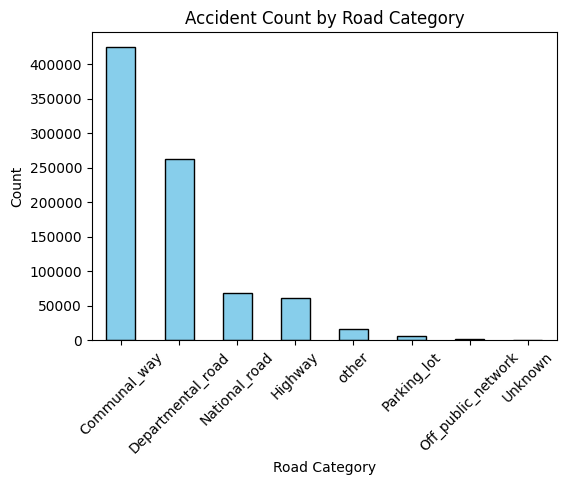

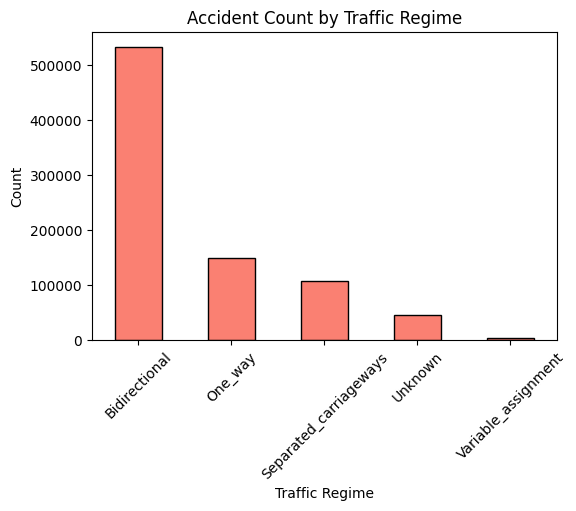

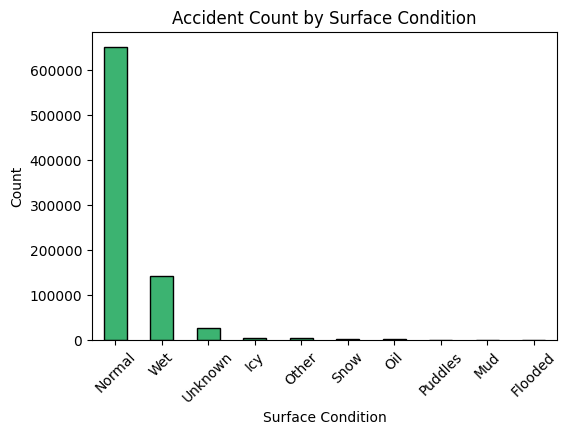

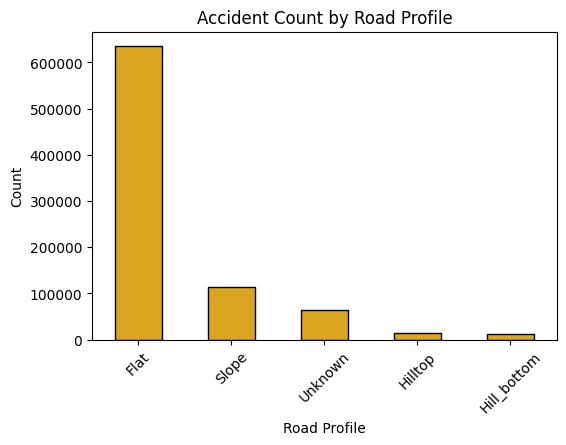

In [24]:
### Visualization

# 1
# Accident Count by Road Category
import matplotlib.pyplot as plt

# Accident count by road category
places["road_category_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color="skyblue",
    edgecolor="black"
)

plt.title("Accident Count by Road Category")
plt.xlabel("Road Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Local roads (communal + departmental) are the most accident-prone — likely due to traffic density and complexity.
# Highways are safer in terms of frequency, but may require separate analysis for severity.
# Unknown values are minimal — good sign for data quality.

#2
# Accident Count by Traffic Regime

import matplotlib.pyplot as plt

# Accident count by traffic regime
places["traffic_regime_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color="salmon",
    edgecolor="black"
)

plt.title("Accident Count by Traffic Regime")
plt.xlabel("Traffic Regime")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Bidirectional roads are clearly the most dangerous — likely due to lack of separation and unpredictable maneuvers.
# One-way and separated roads are safer, supporting infrastructure investment in controlled traffic flow.
# Unknown values should be monitored but don’t dominate.

# 3 
# Accident Count by Surface Condition
import matplotlib.pyplot as plt

places["surface_condition_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Accident Count by Surface Condition")
plt.xlabel("Surface Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Most accidents happen on dry, normal roads, not extreme conditions.
# This reinforces the idea that driver behavior and road design are bigger contributors than weather.
# Wet roads still pose a significant risk — especially in transitional weather.

#4
# Accident count by road profile

places["road_profile_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color="goldenrod",
    edgecolor="black"
)

plt.title("Accident Count by Road Profile")
plt.xlabel("Road Profile")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Flat terrain dominates accident frequency, but not necessarily severity.
# Slopes deserve attention for targeted safety measures (e.g., signage, speed control).
# Unknown values are present but manageable — no major data quality concern.


In [25]:
places.columns

Index(['accident_id', 'road_category', 'road_number', 'road_number_index',
       'road_number_suffix', 'traffic_regime', 'num_lanes', 'milestone',
       'milestone_distance', 'reserved_lane', 'road_profile', 'road_layout',
       'pedestrian_crossing_width', 'road_width', 'surface_condition',
       'infrastructure', 'situation', 'school_zone', 'road_category_label',
       'traffic_regime_label', 'reserved_lane_label', 'road_profile_label',
       'road_layout_label', 'surface_condition_label', 'infrastructure_label',
       'situation_label', 'school_zone_label'],
      dtype='object')

In [26]:
### Cleaning CARACT by Dropping columns before merging in master dataframe for visualisation

drop_cols_places = [
    "road_category", "road_number", "road_number_index", "road_number_suffix",
    "traffic_regime", "milestone", "milestone_distance",
    "reserved_lane", "road_profile", "road_layout",
    "surface_condition", "infrastructure", "situation", "school_zone"
]

places = places.drop(columns=[c for c in drop_cols_places if c in places.columns])

print("Post-drop shape:", places.shape)
print("Remaining columns:", places.columns.tolist())

Post-drop shape: (839985, 13)
Remaining columns: ['accident_id', 'num_lanes', 'pedestrian_crossing_width', 'road_width', 'road_category_label', 'traffic_regime_label', 'reserved_lane_label', 'road_profile_label', 'road_layout_label', 'surface_condition_label', 'infrastructure_label', 'situation_label', 'school_zone_label']


### USERS Dataframe - Auditing, Cleaning and Preprocessing

In [27]:
# Step 1: rename users columns
rename_map = {
    "Num_Acc": "accident_id",
    "num_veh": "vehicle_id",
    "place": "seat_position",
    "catu": "user_category",       # driver, passenger, pedestrian
    "grav": "injury_severity",
    "sexe": "sex",
    "trajet": "journey_purpose",
    "secu": "safety_equipment",
    "locp": "pedestrian_location",
    "actp": "pedestrian_action",
    "etatp": "pedestrian_state",
    "an_nais": "birth_year"
}

users = users.rename(columns=rename_map)
print("Renamed columns:", list(users.columns))

Renamed columns: ['accident_id', 'seat_position', 'user_category', 'injury_severity', 'sex', 'journey_purpose', 'safety_equipment', 'pedestrian_location', 'pedestrian_action', 'pedestrian_state', 'birth_year', 'vehicle_id']


In [28]:
# Inspect users dataframe
print("Columns:", list(users.columns))

print("\nDtypes:")
print(users.dtypes)

print("\nTop missing (up to 10):")
print(users.isna().sum().sort_values(ascending=False).head(10))

print("\nShape:", users.shape)

print("\nSample (first 5 rows):")
print(users.head(5).to_string(index=False))

for c in users.columns:
    if c in users.columns:
        print(f"\n{c} -- n_unique:", users[c].nunique(dropna=True))
        print("value_sample:", users[c].dropna().sort_values().unique()[:25])

Columns: ['accident_id', 'seat_position', 'user_category', 'injury_severity', 'sex', 'journey_purpose', 'safety_equipment', 'pedestrian_location', 'pedestrian_action', 'pedestrian_state', 'birth_year', 'vehicle_id']

Dtypes:
accident_id              int64
seat_position          float64
user_category            int64
injury_severity          int64
sex                      int64
journey_purpose        float64
safety_equipment       float64
pedestrian_location    float64
pedestrian_action      float64
pedestrian_state       float64
birth_year             float64
vehicle_id              object
dtype: object

Top missing (up to 10):
seat_position          100366
safety_equipment        43458
birth_year               2351
pedestrian_action        1773
pedestrian_state         1706
pedestrian_location      1664
journey_purpose           369
accident_id                 0
user_category               0
injury_severity             0
dtype: int64

Shape: (1876005, 12)

Sample (first 5 rows):
 acci

In [29]:
#   safety_equipment_map = {
#   0:  "None",
    
#  # Belt
#    1:  "Seat belt (unspecified usage)",
#    11: "Seat belt - used",
#    12: "Seat belt - not used",
#    13: "Seat belt - usage undetermined",

#    # Helmet
#    2:  "Helmet (unspecified usage)",
#    21: "Helmet - used",
#    22: "Helmet - not used",
#    23: "Helmet - usage undetermined",

#    # Child device
#    3:  "Child device (unspecified usage)",
#    10: "Child device (unspecified)",   # <-- missing earlier
#    20: "Child device (unspecified)",   # <-- missing earlier
#    30: "Child device (unspecified)",
#    31: "Child device - used",
#    32: "Child device - not used",
#   33: "Child device - usage undetermined",

#    # Reflective equipment
#    40: "Reflective equipment (unspecified)",
#    41: "Reflective equipment - used",
#    42: "Reflective equipment - not used",
#    43: "Reflective equipment - usage undetermined",

#    # Other equipment
#    90: "Other equipment (unspecified)",
#    91: "Other equipment - used",
#    92: "Other equipment - not used",
#   93: "Other equipment - usage undetermined"
#  }

# it has 24 labels, keeping all 24 safety_equipment codes is too granular for analysis. 
# splitting the safety_equipment codes into two separate columns (safety_equipment_type and safety_equipment_usage) is the most structured approach.It will preserve the equipment type and separately capture the usage status.This avoids collapsing too much information into one column, while still reducing complexity compared to 24 codes.Also making analysis easier

In [30]:
#mapping

sex_map = {
    1: "Male",
    2: "Female"
}

user_category_map = {
    1: "Driver",
    2: "Passenger",
    3: "Pedestrian",
    4: "Pedestrian_(rollerblade/scooter)"
}

injury_severity_map = {
    1: "Uninjured",
    2: "Killed",
    3: "Injured_Hospitalized",
    4: "Injured_Slight"
}

seat_position_map = {
    0: "Unknown", 9: "Unknown",
    1: "Driver_seat",
    2: "Front_passenger",
    3: "Rear_left",
    4: "Rear_middle",
    5: "Rear_right",
    6: "other_rear",
    7: "other",
    8: "Outside_vehicle",
}

journey_purpose_map = {
    0: "Unknown",
    1: "Home-work",
    2: "Home-school",
    3: "Shopping",
    4: "Professional use",
    5: "Leisure",
    9: "other"
}

pedestrian_location_map = {
    0: "Not_pedestrian",
    1: "On_pavement_>50m_from_crossing",
    2: "On_pavement_<50m_from_crossing",
    3: "On_crossing_no_signal",
    4: "On_crossing_with_signal",
    5: "On_sidewalk",
    6: "On_verge",
    7: "On_refuge/BAU",
    8: "On_against_aisle"
}

pedestrian_action_map = {
    0: "Unknown",
    1: "Walking_in_vehicle_direction",
    2: "Walking_opposite_vehicle_direction",
    3: "Crossing",
    4: "Masked",
    5: "Playing_or_Running",
    6: "With_animal",
    9: "other"
}

pedestrian_state_map = {
    0: "Not_pedestrian",   
    1: "Alone",            
    2: "Accompanied",     
    3: "In_group"     
}

# Define safety equipment type mapping
type_map = {
    0: "None",
    1: "Seat_belt", 11: "Seat_belt", 12: "Seat_belt", 13: "Seat_belt",
    2: "Helmet",    21: "Helmet",    22: "Helmet",    23: "Helmet",
    3: "Child_device", 10: "Child_device", 20: "Child_device",
    30: "Child_device", 31: "Child_device", 32: "Child_device", 33: "Child_device",
    40: "Reflective_equipment",41: "Reflective_equipment", 42: "Reflective_equipment", 43: "Reflective_equipment",
    90: "other",91: "other", 92: "other", 93: "other"
}

# Define safety equipment usage mapping
usage_map = {
    0: "None",
    1: "Unspecified", 2: "Unspecified", 3: "Unspecified", 10: "Unspecified", 20: "Unspecified", 30: "Unspecified",40: "Unspecified", 90: "Unspecified", 
    11: "Used", 21: "Used", 31: "Used", 41: "Used", 91: "Used",
    12: "Not_used", 22: "Not_used", 32: "Not_used", 42: "Not_used", 92: "Not_used",
    13: "Undetermined", 23: "Undetermined", 33: "Undetermined", 43: "Undetermined", 93: "Undetermined"
}

# Apply mappings to create new label columns
users["sex_label"] = users["sex"].map(sex_map)
users["user_category_label"] = users["user_category"].map(user_category_map)
users["injury_severity_label"] = users["injury_severity"].map(injury_severity_map)
users["seat_position_label"] = users["seat_position"].map(seat_position_map)
users["journey_purpose_label"] = users["journey_purpose"].map(journey_purpose_map)
users["pedestrian_location_label"] = users["pedestrian_location"].map(pedestrian_location_map)
users["pedestrian_action_label"] = users["pedestrian_action"].map(pedestrian_action_map)
users["pedestrian_state_label"] = users["pedestrian_state"].map(pedestrian_state_map)

# Safety equipment split into two columns
users["safety_equipment_type"] = users["safety_equipment"].map(type_map)
users["safety_equipment_usage"] = users["safety_equipment"].map(usage_map)

In [31]:
# Check for unmapped codes (NaN values)
print("\n--- Missing Labels Check ---")
for col in [
    "sex_label", "user_category_label", "injury_severity_label",
    "seat_position_label", "journey_purpose_label",
    "pedestrian_location_label", "pedestrian_action_label",
    "pedestrian_state_label", "safety_equipment_type", "safety_equipment_usage"
]:
    missing = users[col].isna().sum()
    print(f"{col}: {missing} unmapped values")

# Fill NaN values with "Unknown" for all mapped columns
users["seat_position_label"] = users["seat_position_label"].fillna("Unknown")
users["journey_purpose_label"] = users["journey_purpose_label"].fillna("Unknown")
users["pedestrian_location_label"] = users["pedestrian_location_label"].fillna("Unknown")
users["pedestrian_action_label"] = users["pedestrian_action_label"].fillna("Unknown")
users["pedestrian_state_label"] = users["pedestrian_state_label"].fillna("Unknown")
users["safety_equipment_type"] = users["safety_equipment_type"].fillna("Unknown")
users["safety_equipment_usage"] = users["safety_equipment_usage"].fillna("Unknown")


# Distribution checks
print("\n--- Distribution Checks ---")
print("Sex:\n", users["sex_label"].value_counts(dropna=False))
print("\nUser Category:\n", users["user_category_label"].value_counts(dropna=False))
print("\nInjury Severity:\n", users["injury_severity_label"].value_counts(dropna=False))
print("\nSeat Position:\n", users["seat_position_label"].value_counts(dropna=False))
print("\nJourney Purpose:\n", users["journey_purpose_label"].value_counts(dropna=False))
print("\nPedestrian Location:\n", users["pedestrian_location_label"].value_counts(dropna=False))
print("\nPedestrian Action:\n", users["pedestrian_action_label"].value_counts(dropna=False))
print("\nPedestrian State:\n", users["pedestrian_state_label"].value_counts(dropna=False))
print("\nSafety Equipment Type:\n", users["safety_equipment_type"].value_counts(dropna=False))
print("\nSafety Equipment Usage:\n", users["safety_equipment_usage"].value_counts(dropna=False))



--- Missing Labels Check ---
sex_label: 0 unmapped values
user_category_label: 0 unmapped values
injury_severity_label: 0 unmapped values
seat_position_label: 100366 unmapped values
journey_purpose_label: 369 unmapped values
pedestrian_location_label: 1664 unmapped values
pedestrian_action_label: 1773 unmapped values
pedestrian_state_label: 1706 unmapped values
safety_equipment_type: 43458 unmapped values
safety_equipment_usage: 43458 unmapped values

--- Distribution Checks ---
Sex:
 sex_label
Male      1259016
Female     616989
Name: count, dtype: int64

User Category:
 user_category_label
Driver                              1397701
Passenger                            319388
Pedestrian                           155649
Pedestrian_(rollerblade/scooter)       3267
Name: count, dtype: int64

Injury Severity:
 injury_severity_label
Uninjured               764874
Injured_Slight          666873
Injured_Hospitalized    393669
Killed                   50589
Name: count, dtype: int64

Seat P

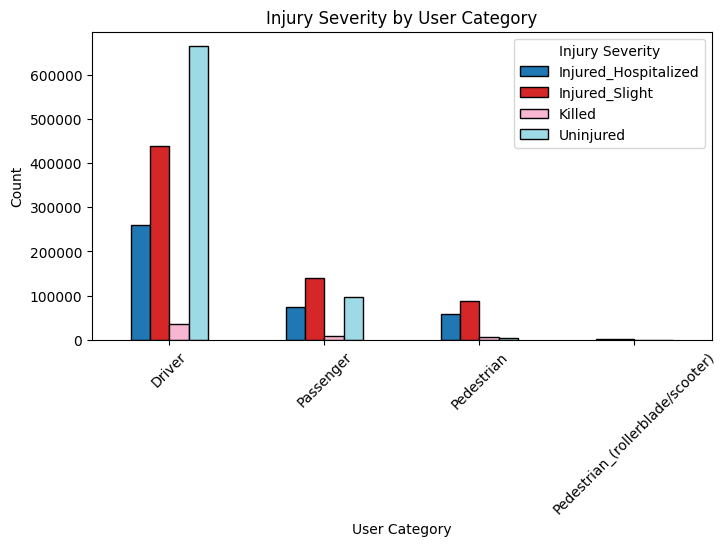

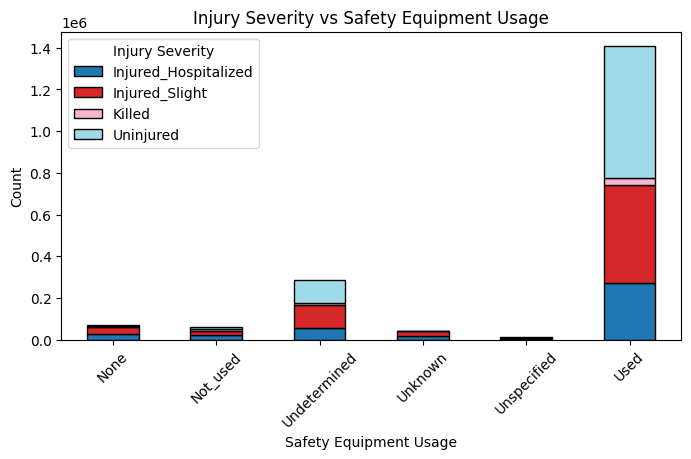

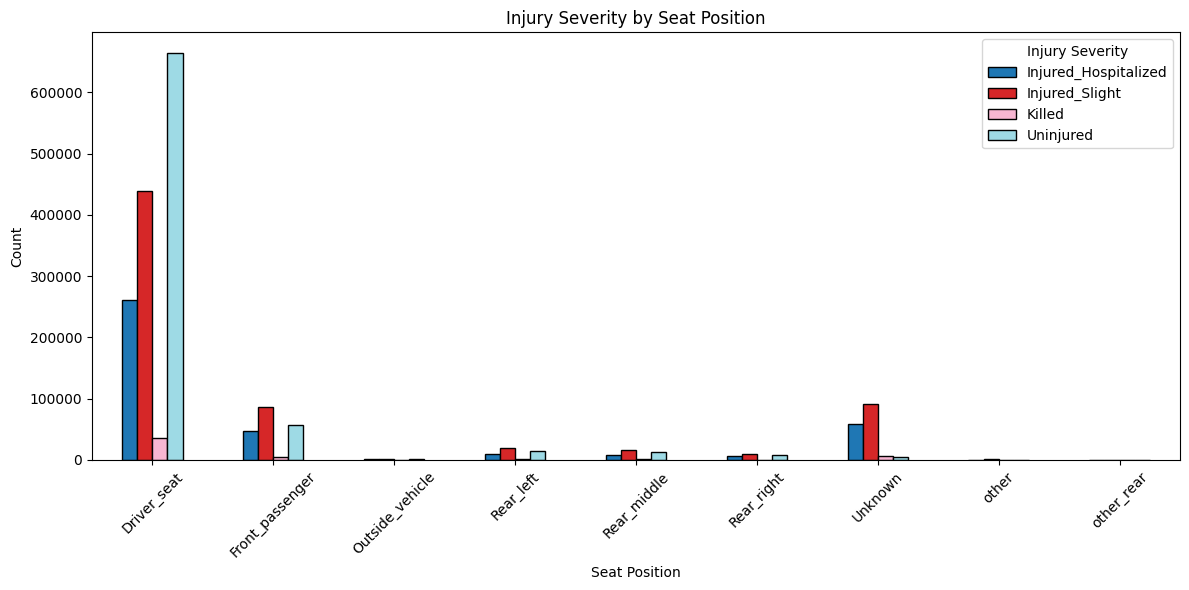

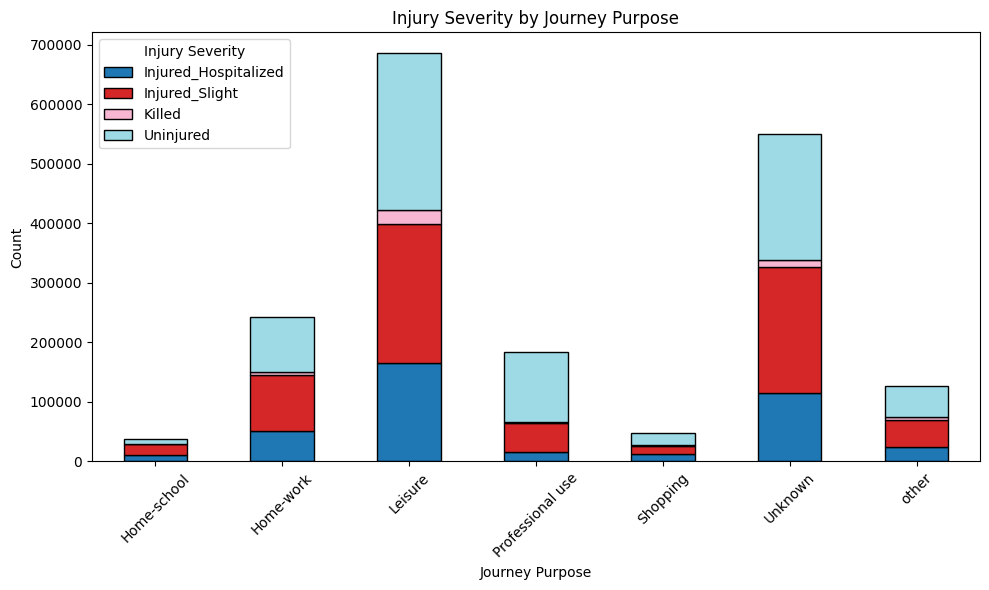

In [32]:
# VISUALIZATION

#1 
# Injury Severity by User Category
# Shows how outcomes differ between drivers, passengers, and pedestrians

import matplotlib.pyplot as plt

# Cross-analysis: Injury Severity vs User Category
cross_tab = users.groupby(["user_category_label", "injury_severity_label"]).size().unstack(fill_value=0)

cross_tab.plot(kind="bar",figsize=(8,4),colormap="tab20",edgecolor="black")

plt.title("Injury Severity by User Category")
plt.xlabel("User Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Injury Severity")
plt.show()

#  Drivers are the most exposed group, but also have the highest chance of walking away uninjured.
# Pedestrians show a concerning proportion of serious injuries and fatalities — even with fewer total cases.

#2
# Cross-analysis: Injury Severity vs Safety Equipment Usage
cross_tab = users.groupby(["safety_equipment_usage", "injury_severity_label"]).size().unstack(fill_value=0)

cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(8,4),
    colormap="tab20",
    edgecolor="black"
)

plt.title("Injury Severity vs Safety Equipment Usage")
plt.xlabel("Safety Equipment Usage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Injury Severity")
plt.show()

#- Used equipment is clearly protective — fewer severe injuries and deaths.
# Not used and Undetermined groups show higher risk — these are critical for safety policy.

#3
# Cross-analysis: Injury Severity vs Seat Position
cross_tab = users.groupby(["seat_position_label", "injury_severity_label"]).size().unstack(fill_value=0)

cross_tab.plot(kind="bar",figsize=(12,6),colormap="tab20",edgecolor="black")

plt.title("Injury Severity by Seat Position")
plt.xlabel("Seat Position")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Injury Severity")
plt.tight_layout()
plt.show()

# Driver seat is the most vulnerable, but also has the highest chance of walking away uninjured.
# Rear seats show a safer profile, supporting the idea that rear passengers are less exposed.
#Outside vehicle and Unknown categories need careful handling in modeling — they may skew results if not filtered properly.

#4
# Cross-analysis: Injury Severity vs Journey Purpose

cross_tab = users.groupby(["journey_purpose_label", "injury_severity_label"]).size().unstack(fill_value=0)

cross_tab.plot( kind="bar",stacked=True, figsize=(10,6), colormap="tab20", edgecolor="black")

plt.title("Injury Severity by Journey Purpose")
plt.xlabel("Journey Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Injury Severity")
plt.tight_layout()
plt.show()



In [33]:
users.columns

Index(['accident_id', 'seat_position', 'user_category', 'injury_severity',
       'sex', 'journey_purpose', 'safety_equipment', 'pedestrian_location',
       'pedestrian_action', 'pedestrian_state', 'birth_year', 'vehicle_id',
       'sex_label', 'user_category_label', 'injury_severity_label',
       'seat_position_label', 'journey_purpose_label',
       'pedestrian_location_label', 'pedestrian_action_label',
       'pedestrian_state_label', 'safety_equipment_type',
       'safety_equipment_usage'],
      dtype='object')

In [34]:
### Cleaning USERS by Dropping columns before merging in master dataframe for visualisation

drop_cols_users = [
    "seat_position", "user_category", "injury_severity", "sex", "journey_purpose",
    "safety_equipment", "pedestrian_location", "pedestrian_action", "pedestrian_state"
]

users = users.drop(columns=[c for c in drop_cols_users if c in users.columns])

print("Post-drop shape:", users.shape)
print("Remaining columns:", users.columns.tolist())

Post-drop shape: (1876005, 13)
Remaining columns: ['accident_id', 'birth_year', 'vehicle_id', 'sex_label', 'user_category_label', 'injury_severity_label', 'seat_position_label', 'journey_purpose_label', 'pedestrian_location_label', 'pedestrian_action_label', 'pedestrian_state_label', 'safety_equipment_type', 'safety_equipment_usage']


### VEHICLES Dataframe - Auditing, Cleaning and Preprocessing

In [35]:
# Step 2: rename vehicles columns
rename_map = {
    "Num_Acc": "accident_id",
    "num_veh": "vehicle_id",
    "senc": "traffic_direction",
    "catv": "vehicle_category",
    "occutc": "occupants",
    "obs": "fixed_obstacle",
    "obsm": "mobile_obstacle",
    "choc": "impact_point",
    "manv": "manoeuvre"
}

vehicles = vehicles.rename(columns=rename_map)
print("Renamed columns:", list(vehicles.columns))

Renamed columns: ['accident_id', 'traffic_direction', 'vehicle_category', 'occupants', 'fixed_obstacle', 'mobile_obstacle', 'impact_point', 'manoeuvre', 'vehicle_id']


In [36]:
#Auditing

# Basic structure and memory usage
print(vehicles.info())

print("\nDtypes:")
print(vehicles.dtypes)

print("\nTop missing (up to 10):")
print(vehicles.isna().sum().sort_values(ascending=False).head(10))

print("\nSample (first 5 rows):")
print(vehicles.head(5).to_string(index=False))

# Shape and column names
print("Shape:", vehicles.shape)
print("Columns:", vehicles.columns.tolist())


for c in vehicles.columns:
    if c in vehicles.columns:
        print(f"\n{c} -- n_unique:", vehicles[c].nunique(dropna=True))
        print("value_sample:", vehicles[c].dropna().sort_values().unique()[:35])

# Missing values per column
print(vehicles.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433389 entries, 0 to 1433388
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   accident_id        1433389 non-null  int64  
 1   traffic_direction  1433317 non-null  float64
 2   vehicle_category   1433389 non-null  int64  
 3   occupants          1433389 non-null  int64  
 4   fixed_obstacle     1432627 non-null  float64
 5   mobile_obstacle    1432788 non-null  float64
 6   impact_point       1433160 non-null  float64
 7   manoeuvre          1433083 non-null  float64
 8   vehicle_id         1433389 non-null  object 
dtypes: float64(5), int64(3), object(1)
memory usage: 98.4+ MB
None

Dtypes:
accident_id            int64
traffic_direction    float64
vehicle_category       int64
occupants              int64
fixed_obstacle       float64
mobile_obstacle      float64
impact_point         float64
manoeuvre            float64
vehicle_id            object


In [37]:
#For vehicle_category -- n_unique: 33, fixed_obstacle -- n_unique: 17 and manoeuvre -- n_unique: 25 -
#instead of keeping dozens of fine‑grained codes, we can group them into broader, analysis‑friendly categories.

#what we have is 
#vehicle_category_map = {1: "Bicycle",2: "Moped <50cc",3: "Motorcycle <125cc",4: "Motorcycle >125cc",5: "Motorcycle with sidecar",6: "Light quadricycle",7: "Passenger car",
#                        8: "Utility vehicle",9: "Truck <3.5t",10: "Truck 3.5–7.5t",11: "Truck >7.5t",12: "Road tractor",13: "Agricultural tractor",14: "Bus",15: "Coach",
#                        16: "Tramway",17: "Special vehicle", 18: "Train",19: "Other vehicle",20: "Scooter",21: "Electric scooter",30: "Quad >50cc",31: "Mini-motorbike",
#                        32: "Other two-wheel motor vehicle",33: "Other three-wheel motor vehicle",34: "Other four-wheel motor vehicle",35: "Segway",36: "Electric bicycle",
#                        37: "Motorized wheelchair",38: "Personal mobility device",39: "Other personal mobility",40: "Unknown vehicle",99: "Unspecified"}#####
#
#fixed_obstacle_map = { 0: "None", 1: "Vehicle parked", 2: "Tree", 3: "Post", 4: "Wall", 5: "Rail/Barrier", 6: "Building", 7: "Ditch", 8: "Embankment", 
#                      9: "Other fixed obstacle", 10: "Central reservation",11: "Bridge pillar",12: "Tunnel wall",13: "Fence",14: "Traffic island",
#                      15: "Other infrastructure",16: "Animal (fixed)",}###
#
#manoeuvre_map = {0: "No manoeuvre",1: "Straight ahead",2: "Turning left",3: "Turning right",4: "U-turn",5: "Reversing",6: "Changing lane left",
#                 7: "Changing lane right",8: "Overtaking", 9: "Parking", 10: "Starting", 11: "Stopping", 12: "Avoiding obstacle left", 13: "Avoiding obstacle right", 
#                 14: "Crossing intersection", 15: "Entering roundabout", 16: "Leaving roundabout", 17: "Other manoeuvre", 18: "Emergency manoeuvre", 19: "Slipping/skidding", 
#                 20: "Loss of control", 21: "Pedestrian interaction", 22: "Animal interaction",23: "Other special manoeuvre",24: "Unknown manoeuvre"}

In [38]:
## mapping

traffic_direction_map = {
    0: "Same_direction",
    1: "Opposite_direction",
    2: "Other/Unknown"
}
vehicle_category_grouped = {
    1: "Cycle", 2: "Cycle", 36: "Cycle",   # bicycles, mopeds, e-bikes
    3: "Motorcycle", 4: "Motorcycle", 5: "Motorcycle", 20: "Motorcycle", 21: "Motorcycle", 30: "Motorcycle", 31: "Motorcycle", 32: "Motorcycle", 33: "Motorcycle", 34: "Motorcycle",
    6: "Car(Quad/Passenger)", 7: "Car(Quad/Passenger)",
    35: "Personal mobility", 37: "Personal mobility", 38: "Personal mobility", 39: "Personal mobility",
    8: "Utility(Truck/Agri)",9: "Utility(Truck/Agri)", 10: "Utility(Truck/Agri)", 11: "Utility(Truck/Agri)", 12: "Utility(Truck/Agri)",13: "Utility(Truck/Agri)",
    14: "Bus/Coach", 15: "Bus/Coach",
    16: "Tram/Train", 18: "Tram/Train",
    17: "other", 19: "other", 40: "other", 99: "other"
}
# reduces 33 categories down to 8 groups

fixed_obstacle_grouped = {
    0: "None",
    1: "Parked_vehicle",
    2: "Tree/Vegetation",
    3: "Post/Pole",
    4: "Wall/Building", 6: "Wall/Building",
    5: "Barrier/Rail/Fence", 10: "Barrier/Rail/Fence", 11: "Barrier/Rail/Fence", 12: "Barrier/Rail/Fence", 13: "Barrier/Rail/Fence",
    7: "Ditch/Embankment", 8: "Ditch/Embankment",
    9: "other",  15: "other", 14: "other", 16: "other"
}
# This reduces from 17 to 7 groups

mobile_obstacle_map = {
    0: "None",
    1: "Pedestrian",
    2: "Cyclist",
    4: "Animal (moving)",
    5: "Other vehicle",
    6: "Train",
    9: "other"
}

impact_point_map = {
    0: "No_impact",
    1: "Front",
    2: "Front_right",
    3: "Right_side",
    4: "Rear_right",
    5: "Rear",
    6: "Rear_left",
    7: "Left_side",
    8: "Front_left",
    9: "Multiple impacts"
}

manoeuvre_grouped = {
    0: "None",
    1: "Straight_ahead",
    2: "Turning", 3: "Turning", 14: "Turning", 4: "Turning",
    5: "Reversing",
    6: "Lane_change/Overtaking", 7:  "Lane_change/Overtaking", 8:  "Lane_change/Overtaking",
    9: "Park/Start/Stop", 10: "Park/Start/Stop", 11: "Park/Start/Stop",
    12: "Avoiding_obstacle", 13: "Avoiding_obstacle",
    15: "Roundabout", 16: "Roundabout",
    17: "other", 23: "other", 24: "other",
    18: "Emergency_manoeuvre",
    19: "Loss_of_control", 20: "Loss_of_control",
    21: "Interaction", 22: "Interaction"
}
# This reduces from 25 to 12 groups

vehicles["traffic_direction_label"] = vehicles["traffic_direction"].map(traffic_direction_map)
vehicles["vehicle_category_label"] = vehicles["vehicle_category"].map(vehicle_category_grouped)
vehicles["fixed_obstacle_label"] = vehicles["fixed_obstacle"].map(fixed_obstacle_grouped)
vehicles["mobile_obstacle_label"] = vehicles["mobile_obstacle"].map(mobile_obstacle_map)
vehicles["impact_point_label"] = vehicles["impact_point"].map(impact_point_map)
vehicles["manoeuvre_label"] = vehicles["manoeuvre"].map(manoeuvre_grouped)


In [39]:
# Check if any labels are missing (NaN after mapping)
print("\n--- Missing label counts ---")
print("Traffic direction:", vehicles["traffic_direction_label"].isna().sum())
print("Vehicle category:", vehicles["vehicle_category_label"].isna().sum())
print("Fixed obstacle:", vehicles["fixed_obstacle_label"].isna().sum())
print("Mobile obstacle:", vehicles["mobile_obstacle_label"].isna().sum())
print("Impact point:", vehicles["impact_point_label"].isna().sum())
print("Manoeuvre:", vehicles["manoeuvre_label"].isna().sum())

# Check unique values in each new label column
print("\n--- Unique labels ---")
print("Traffic direction:", vehicles["traffic_direction_label"].unique())
print("Vehicle category:", vehicles["vehicle_category_label"].unique())
print("Fixed obstacle:", vehicles["fixed_obstacle_label"].unique())
print("Mobile obstacle:", vehicles["mobile_obstacle_label"].unique())
print("Impact point:", vehicles["impact_point_label"].unique())
print("Manoeuvre:", vehicles["manoeuvre_label"].unique())


--- Missing label counts ---
Traffic direction: 72
Vehicle category: 0
Fixed obstacle: 762
Mobile obstacle: 601
Impact point: 229
Manoeuvre: 306

--- Unique labels ---
Traffic direction: ['Same_direction' 'Opposite_direction' 'Other/Unknown' nan]
Vehicle category: ['Car(Quad/Passenger)' 'Cycle' 'Motorcycle' 'Utility(Truck/Agri)' 'other'
 'Bus/Coach' 'Personal mobility' 'Tram/Train']
Fixed obstacle: ['None' 'Wall/Building' 'other' 'Tree/Vegetation' 'Barrier/Rail/Fence'
 'Ditch/Embankment' 'Post/Pole' 'Parked_vehicle' nan]
Mobile obstacle: ['None' 'Pedestrian' 'Cyclist' 'other' 'Animal (moving)' 'Train'
 'Other vehicle' nan]
Impact point: ['Front' 'Left_side' 'Rear_left' 'Front_left' 'Right_side' 'Front_right'
 'No_impact' 'Multiple impacts' 'Rear' 'Rear_right' nan]
Manoeuvre: ['Straight_ahead' 'Roundabout' 'other' 'Avoiding_obstacle' 'Interaction'
 'None' 'Park/Start/Stop' 'Reversing' 'Loss_of_control' 'Turning'
 'Lane_change/Overtaking' 'Emergency_manoeuvre' nan]


In [40]:
## more cleaning

# 1. filling Nans

vehicles["traffic_direction_label"] = vehicles["traffic_direction_label"].fillna("Unknown")
vehicles["fixed_obstacle_label"]   = vehicles["fixed_obstacle_label"].fillna("Unknown")
vehicles["mobile_obstacle_label"]  = vehicles["mobile_obstacle_label"].fillna("Unknown")
vehicles["impact_point_label"]     = vehicles["impact_point_label"].fillna("Unknown")
vehicles["manoeuvre_label"]        = vehicles["manoeuvre_label"].fillna("Unknown")

# 2. Check for outliers in occupants
vehicles["occupants_group"] = vehicles["occupants"].apply(lambda x: str(x) if x <= 10 else "10+")

# 3. Check duplicates
duplicates = vehicles.duplicated(subset=["accident_id", "vehicle_id"]).sum()
print("Duplicate rows:", duplicates)

#4. checking datatypes
print("\n")
print(vehicles.dtypes)



Duplicate rows: 0


accident_id                  int64
traffic_direction          float64
vehicle_category             int64
occupants                    int64
fixed_obstacle             float64
mobile_obstacle            float64
impact_point               float64
manoeuvre                  float64
vehicle_id                  object
traffic_direction_label     object
vehicle_category_label      object
fixed_obstacle_label        object
mobile_obstacle_label       object
impact_point_label          object
manoeuvre_label             object
occupants_group             object
dtype: object


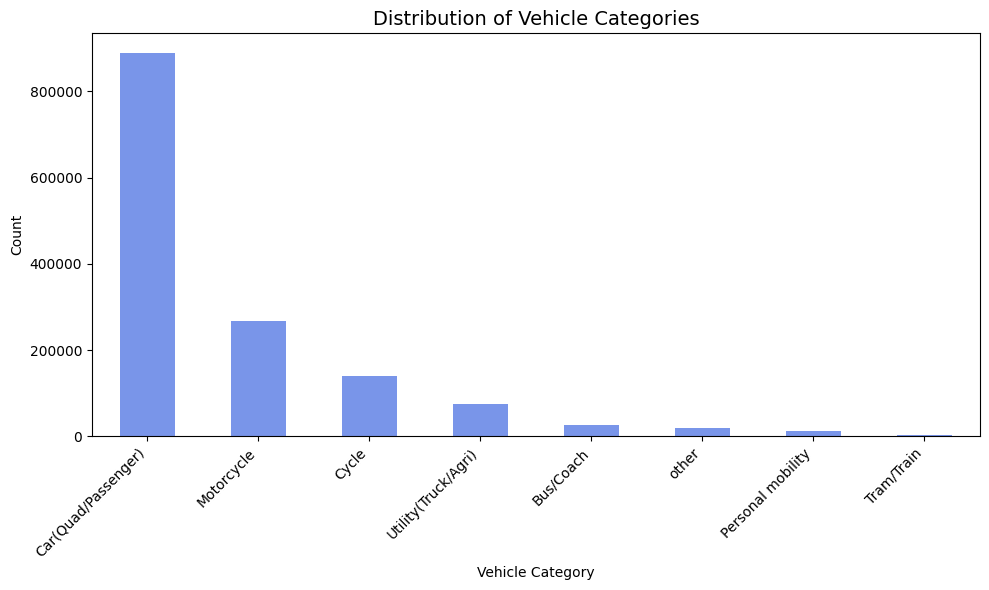

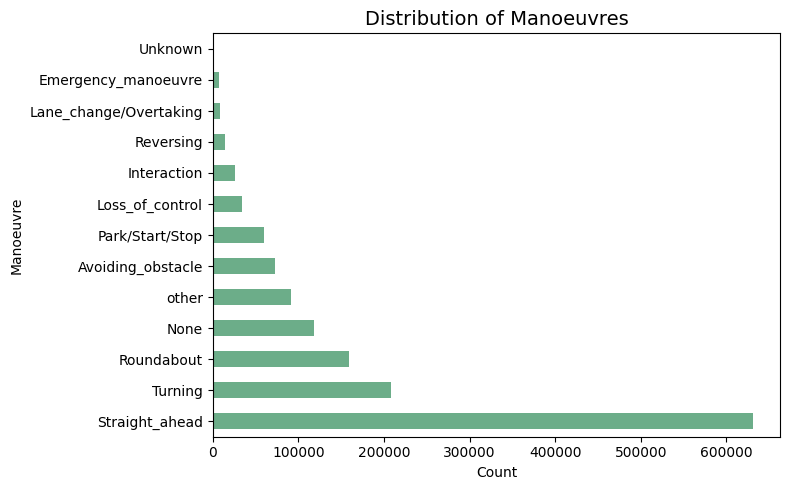

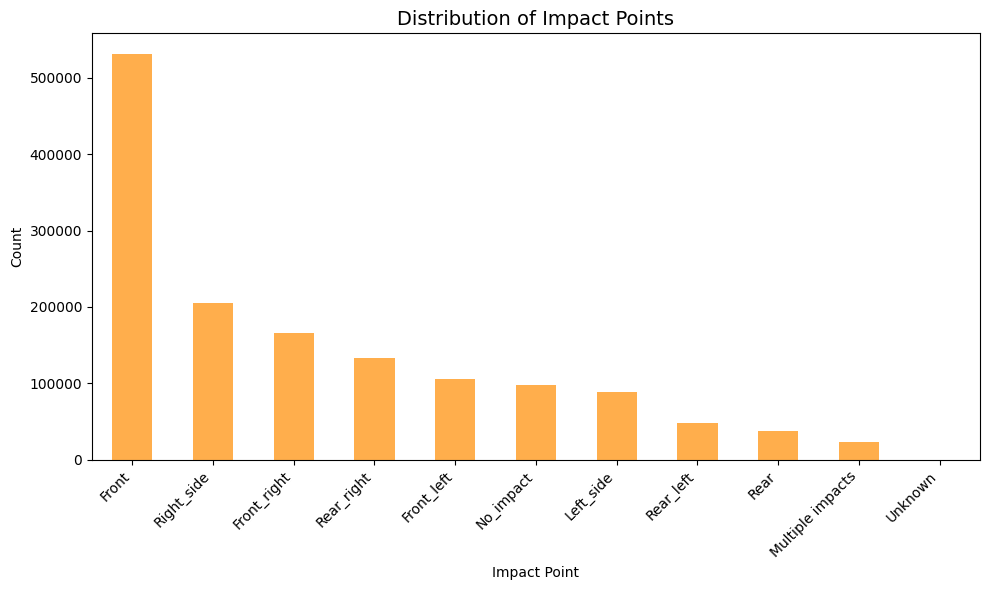

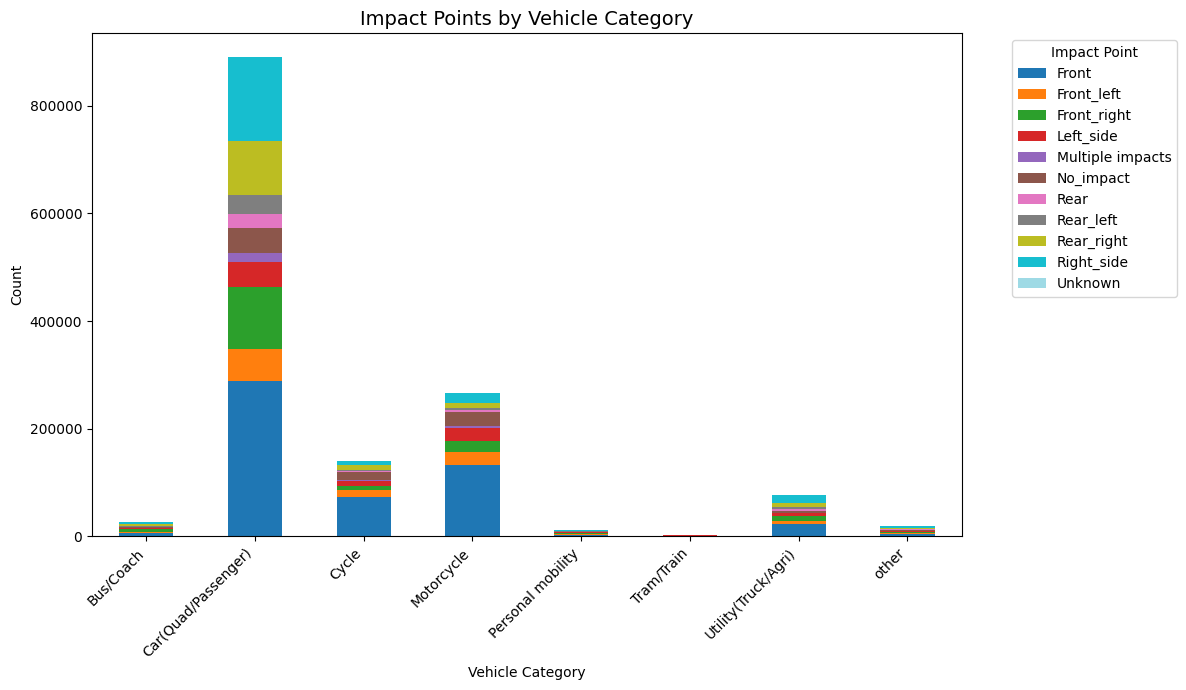

In [41]:
# visualization

# 1.
# Bar Chart — Vehicle Category Distribution
# Shows which vehicle types are most involved in accidents (cars vs motorcycles vs cycles vs trucks).

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
vehicles["vehicle_category_label"].value_counts().plot(kind="bar", color="royalblue", alpha=0.7)
plt.title("Distribution of Vehicle Categories", fontsize=14)
plt.xlabel("Vehicle Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#Cars dominate, but motorcycles and cycles together form a large share.

#2 
# 2. Horizontal Bar Chart — Manoeuvre Distribution
# Highlights the most common manoeuvres before accidents

plt.figure(figsize=(8,5))
vehicles["manoeuvre_label"].value_counts().plot(kind="barh", color="seagreen", alpha=0.7)
plt.title("Distribution of Manoeuvres", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Manoeuvre")
plt.tight_layout()
plt.show()

# Straight‑ahead dominates, but turning and roundabouts are also major contributors

#3. Bar Chart — Impact Point Distributio
# Shows where vehicles are most often hit (front, side, rear)

plt.figure(figsize=(10,6))
vehicles["impact_point_label"].value_counts().plot(kind="bar", color="darkorange", alpha=0.7)
plt.title("Distribution of Impact Points", fontsize=14)
plt.xlabel("Impact Point")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Front collisions dominate, side impacts highlight intersection risks

# 4. Stacked Bar Chart — Vehicle Category vs Impact Point
# Combines two dimensions: which vehicle types tend to be hit where.

impact_by_category = vehicles.groupby(["vehicle_category_label", "impact_point_label"]).size().unstack(fill_value=0)

impact_by_category.plot(kind="bar", stacked=True, figsize=(12,7), colormap="tab20")
plt.title("Impact Points by Vehicle Category", fontsize=14)
plt.xlabel("Vehicle Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Impact Point", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#Cars dominate impacts,but motorcycles have approximate 50% front impacts




In [42]:
vehicles.columns

Index(['accident_id', 'traffic_direction', 'vehicle_category', 'occupants',
       'fixed_obstacle', 'mobile_obstacle', 'impact_point', 'manoeuvre',
       'vehicle_id', 'traffic_direction_label', 'vehicle_category_label',
       'fixed_obstacle_label', 'mobile_obstacle_label', 'impact_point_label',
       'manoeuvre_label', 'occupants_group'],
      dtype='object')

In [43]:
### Cleaning VEHICLES by Dropping columns before merging in master dataframe for visualisation

drop_cols_vehicles = [
    "traffic_direction", "vehicle_category", "occupants",
    "fixed_obstacle", "mobile_obstacle", "impact_point", "manoeuvre",
    "fixed_obstacle_label"
]

vehicles = vehicles.drop(columns=[c for c in drop_cols_vehicles if c in vehicles.columns])

print("Post-drop shape:", vehicles.shape)
print("Remaining columns:", vehicles.columns.tolist())

Post-drop shape: (1433389, 8)
Remaining columns: ['accident_id', 'vehicle_id', 'traffic_direction_label', 'vehicle_category_label', 'mobile_obstacle_label', 'impact_point_label', 'manoeuvre_label', 'occupants_group']


### HOLIDAYS Dataframe - Auditing, Cleaning and Preprocessing

In [44]:
# Inspect holiday dataframe
print("Columns:", list(holidays.columns))

print("\nDtypes:")
print(holidays.dtypes)

print("\nTop missing (up to 10):")
print(holidays.isna().sum().sort_values(ascending=False).head(10))

print("\nShape:", holidays.shape)

print("\nSample (first 5 rows):")
print(holidays.head(5).to_string(index=False))

Columns: ['ds', 'holiday']

Dtypes:
ds         object
holiday    object
dtype: object

Top missing (up to 10):
ds         0
holiday    0
dtype: int64

Shape: (132, 2)

Sample (first 5 rows):
        ds               holiday
2005-01-01              New year
2005-03-28         Easter Monday
2005-05-01            Labour Day
2005-05-05    Ascension Thursday
2005-05-08 Victory in Europe Day


In [45]:
# Step 1: rename columns
holidays = holidays.rename(columns={"ds": "date", "holiday": "holiday_name"})

# Step 2: convert to datetime
holidays["date"] = pd.to_datetime(holidays["date"], errors="coerce")

# Step 3: add holiday flag
holidays["is_holiday"] = 1

# Step 4: drop duplicates
holidays = holidays.drop_duplicates(subset="date")

# Step 5: clean holiday_name
holidays["holiday_name"] = holidays["holiday_name"].str.strip().fillna("None")

print("Cleaned holidays shape:", holidays.shape)
print(holidays.head())

Cleaned holidays shape: (131, 3)
        date           holiday_name  is_holiday
0 2005-01-01               New year           1
1 2005-03-28          Easter Monday           1
2 2005-05-01             Labour Day           1
3 2005-05-05     Ascension Thursday           1
4 2005-05-08  Victory in Europe Day           1


### DATA MERGING and Creation of Master Dataframe ACC (short for Accidents)

In [46]:
# List of dataframes to check
dfs = {
    "users": users,
    "caract": caract,
    "places": places,
    "vehicles": vehicles,
    "holidays": holidays
}

for name, df in dfs.items():
    print(f"\n=== {name.upper()} DATAFRAME INFO ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing values:\n", df.isna().sum().head(10))  # top 10 columns with NaNs
    print("\nSample rows:\n", df.head(3))
    print("="*60)


=== USERS DATAFRAME INFO ===
Shape: (1876005, 13)
Columns: ['accident_id', 'birth_year', 'vehicle_id', 'sex_label', 'user_category_label', 'injury_severity_label', 'seat_position_label', 'journey_purpose_label', 'pedestrian_location_label', 'pedestrian_action_label', 'pedestrian_state_label', 'safety_equipment_type', 'safety_equipment_usage']

Dtypes:
 accident_id                    int64
birth_year                   float64
vehicle_id                    object
sex_label                     object
user_category_label           object
injury_severity_label         object
seat_position_label           object
journey_purpose_label         object
pedestrian_location_label     object
pedestrian_action_label       object
pedestrian_state_label        object
safety_equipment_type         object
safety_equipment_usage        object
dtype: object

Missing values:
 accident_id                     0
birth_year                   2351
vehicle_id                      0
sex_label                    

In [47]:
# Final Cleaning Checklist Before Merge

# Key Columns Consistency
print(caract["accident_id"].dtype, places["accident_id"].dtype, vehicles["accident_id"].dtype, users["accident_id"].dtype)
print(caract["date"].dtype, holidays["date"].dtype)

# Duplicate Keys
caract = caract.drop_duplicates(subset="accident_id")
places = places.drop_duplicates(subset="accident_id")
vehicles = vehicles.drop_duplicates(subset=["accident_id","vehicle_id"])
users = users.drop_duplicates(subset=["accident_id","vehicle_id"])
holidays = holidays.drop_duplicates(subset="date")

# Missing Values in Keys
print(caract["accident_id"].isna().sum())
print(places["accident_id"].isna().sum())
print(vehicles[["accident_id","vehicle_id"]].isna().sum())
print(users[["accident_id","vehicle_id"]].isna().sum())
print(holidays["date"].isna().sum())


#- Ensure is_holiday is binary (0/1) and no NaNs remain.
holidays["is_holiday"] = holidays["is_holiday"].fillna(1).astype(int)

int64 int64 int64 int64
datetime64[ns] datetime64[ns]
0
0
accident_id    0
vehicle_id     0
dtype: int64
accident_id    0
vehicle_id     0
dtype: int64
0


In [48]:
# MERGE

# Step 1: start with accident-level info
acc = caract.copy()

# Step 2: merge places
acc = acc.merge(places, how="left", on="accident_id")

# Step 3: merge vehicles
acc = acc.merge(vehicles, how="left", on="accident_id")

# Step 4: merge users (linked via accident_id + vehicle_id)
acc = acc.merge(users, how="left", on=["accident_id","vehicle_id"])

# Step 5: merge holidays (linked via date)
acc = acc.merge(holidays, how="left", on="date")

# Fill holiday flags for non-holiday rows
acc["is_holiday"] = acc["is_holiday"].fillna(0).astype(int)
acc["holiday_name"] = acc["holiday_name"].fillna("Not a holiday")

print("Final acc shape:", acc.shape)
print(acc.head())

Final acc shape: (1433389, 52)
    accident_id  year  month  day    lighting_label           urban_label  \
0  201600000001  2016      2    1          Daylight         Built_up_area   
1  201600000001  2016      2    1          Daylight         Built_up_area   
2  201600000002  2016      3   16          Daylight         Built_up_area   
3  201600000003  2016      7   13          Daylight  Out_of_agglomeration   
4  201600000004  2016      8   15  Twilight_or_dawn         Built_up_area   

    intersection_label weather_label    collision_label     gps_label  ...  \
0  Out_of_intersection        Cloudy  Side_two_vehicles  Manual_entry  ...   
1  Out_of_intersection        Cloudy  Side_two_vehicles  Manual_entry  ...   
2           Roundabout        Normal    Other_collision  Manual_entry  ...   
3  Out_of_intersection        Normal    Other_collision  Manual_entry  ...   
4  Out_of_intersection      Dazzling  Side_two_vehicles  Manual_entry  ...   

   injury_severity_label  seat_positi

In [49]:
# Post-Merge Sanity Checks

# Check duplicates
print("Duplicate accident IDs:", acc["accident_id"].duplicated().sum())

# Check missing values in key columns
print(acc[["accident_id","date","vehicle_id"]].isna().sum())

# Quick distribution of holiday flag
print(acc["is_holiday"].value_counts())

Duplicate accident IDs: 593404
accident_id    0
date           0
vehicle_id     0
dtype: int64
is_holiday
0    1403380
1      30009
Name: count, dtype: int64


In [50]:
#What the Results Mean
#1 -  Duplicate Accident IDs: 593,404
#- This is expected because of the one-to-many relationships:
#- Each accident (accident_id) can involve multiple vehicles.
#- Each vehicle can involve multiple users (driver + passengers).
#- So when we merge caract (accident-level) with vehicles and users, the accident rows get replicated.
#- This doesn’t mean bad data — it means the master dataframe acc is now granular at the user/vehicle level, not just accident-level.
#If we want to analyze accident-level statistics, we'll need to deduplicate by accident_id or aggregate.
#If we want to analyze user-level or vehicle-level statistics, keep the duplicates — they represent real entities.

#2 - Missing Values in Keys
#- accident_id, date, vehicle_id → all show 0 missing.
#- This confirms the merge was clean and no join keys were lost.

#33 Holiday Flag Distribution
#- Non-holiday accidents: 1,403,380
#- Holiday accidents: 30,009
#- Holidays account for ~2% of all accidents.
#- This is consistent: most accidents happen on regular days, but holidays are still a meaningful subset for analysis.

#Next Steps
#Option A: Accident-Level Analysis
#If we want to study accident counts, trends, or holiday effects, deduplicate.

#Option B: User/Vehicle-Level Analysis
#If we want to study injury severity, seat position, safety equipment, keep the duplicates — they represent each person/vehicle involved.

#PLAN - 
#Phase 1 - User/Vehicle-Level Analysis
#Phase 2: Accident-Level Analysis - After deduplicatio


### DATA VISUALIZATION - PHASE 1 and 2

#### Phase 1 Visualizations (User/Vehicle-Level)

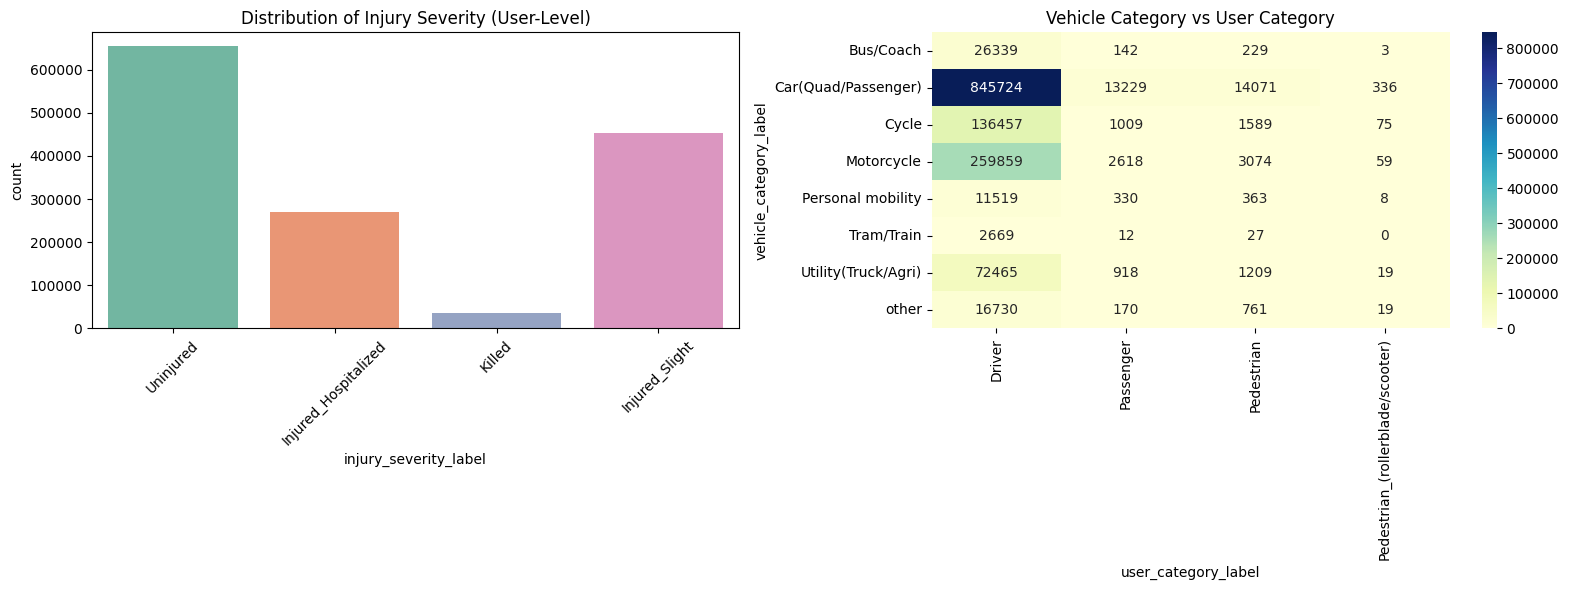

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Injury Severity Distribution (fixed for seaborn v0.14+)
sns.countplot(data=acc, 
              x="injury_severity_label", 
              hue="injury_severity_label",   # add hue
              palette="Set2", 
              ax=axes[0], 
              legend=False)                  # avoid duplicate legend
axes[0].set_title("Distribution of Injury Severity (User-Level)")
axes[0].tick_params(axis='x', rotation=45)

# 2. Vehicle Category vs User Category (Heatmap)
ct = pd.crosstab(acc["vehicle_category_label"], acc["user_category_label"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Vehicle Category vs User Category")

plt.tight_layout()
plt.show()

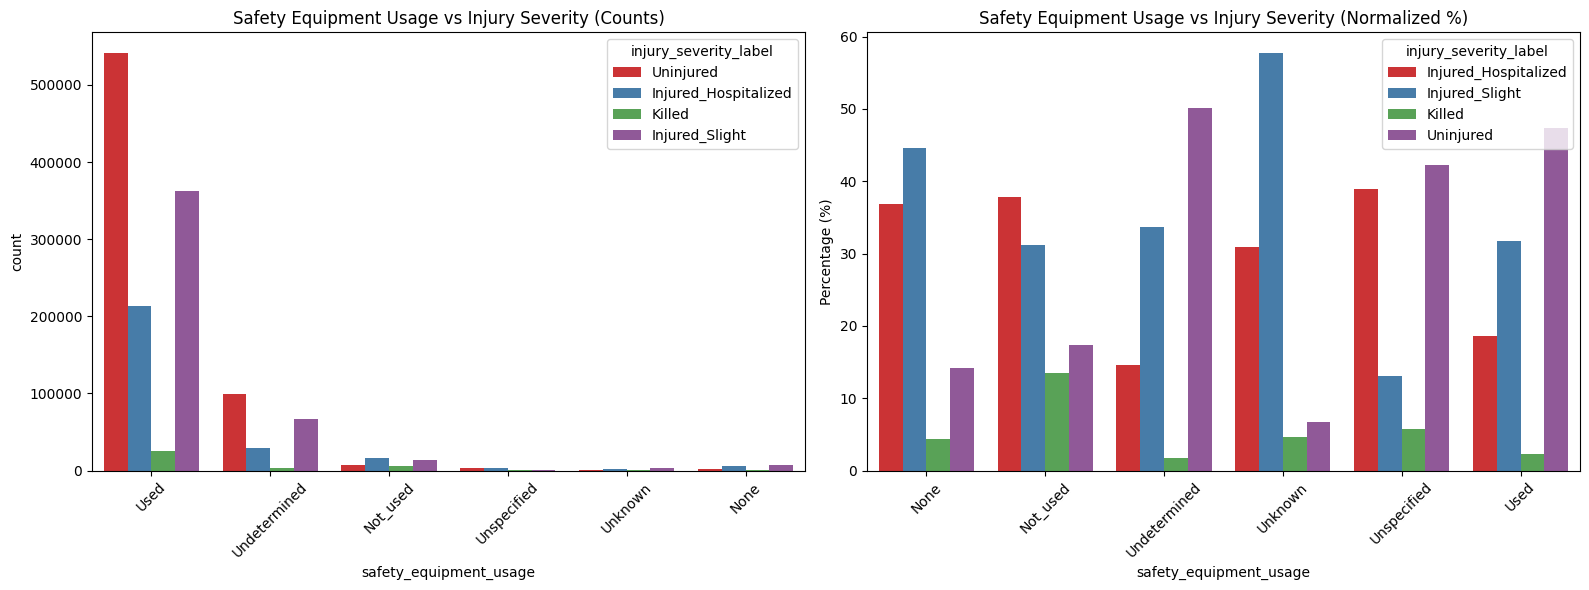

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Safety Equipment Usage vs Injury Severity (Counts)
sns.countplot(data=acc, 
              x="safety_equipment_usage", 
              hue="injury_severity_label", 
              palette="Set1", ax=axes[0])
axes[0].set_title("Safety Equipment Usage vs Injury Severity (Counts)")
axes[0].tick_params(axis='x', rotation=45)

# 2. Safety Equipment Usage vs Injury Severity (Normalized %)
equip_severity = (
    acc.groupby(["safety_equipment_usage","injury_severity_label"])
       .size()
       .reset_index(name="count")
)
equip_severity["percentage"] = equip_severity.groupby("safety_equipment_usage")["count"].transform(lambda x: 100 * x / x.sum())

sns.barplot(data=equip_severity, 
            x="safety_equipment_usage", 
            y="percentage", 
            hue="injury_severity_label", 
            palette="Set1", ax=axes[1])
axes[1].set_title("Safety Equipment Usage vs Injury Severity (Normalized %)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

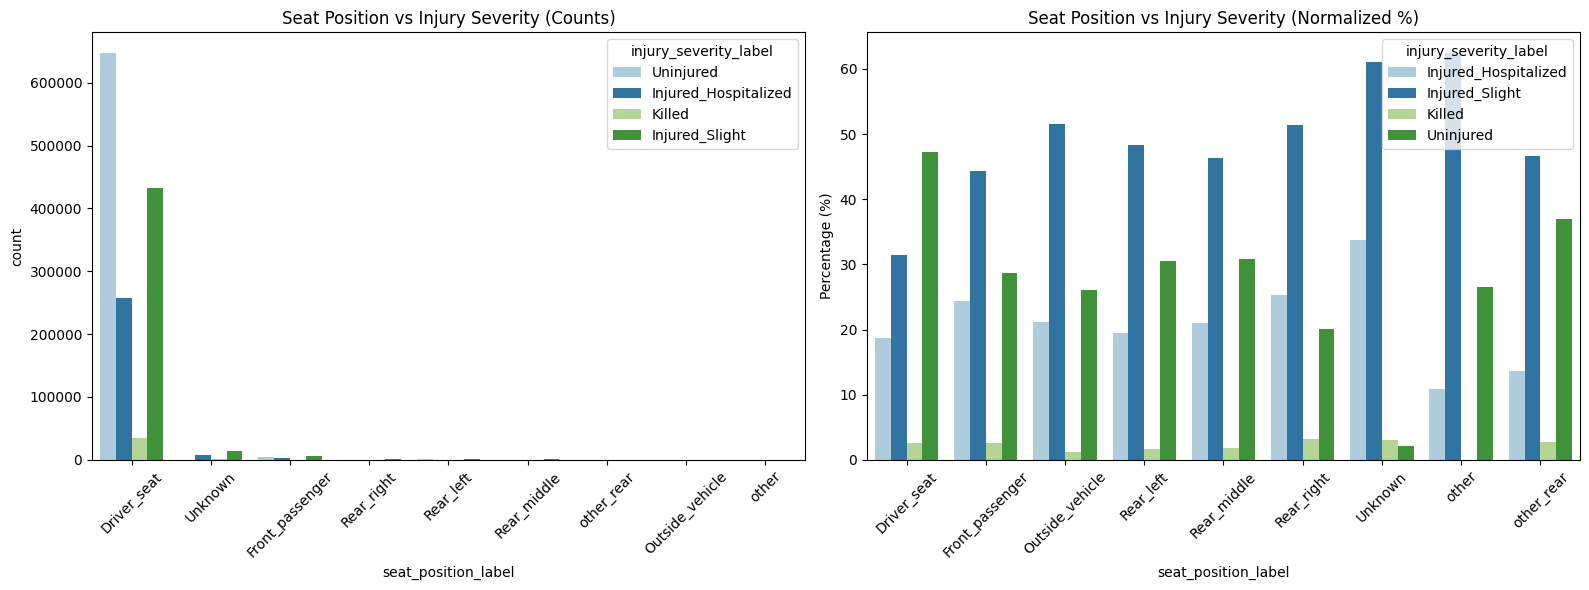

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Seat Position vs Injury Severity (Counts)
sns.countplot(data=acc, 
              x="seat_position_label", 
              hue="injury_severity_label", 
              palette="Paired", ax=axes[0])
axes[0].set_title("Seat Position vs Injury Severity (Counts)")
axes[0].tick_params(axis='x', rotation=45)

# 2. Seat Position vs Injury Severity (Normalized %)
seat_severity = (
    acc.groupby(["seat_position_label","injury_severity_label"])
       .size()
       .reset_index(name="count")
)
seat_severity["percentage"] = seat_severity.groupby("seat_position_label")["count"].transform(lambda x: 100 * x / x.sum())

sns.barplot(data=seat_severity, 
            x="seat_position_label", 
            y="percentage", 
            hue="injury_severity_label", 
            palette="Paired", ax=axes[1])
axes[1].set_title("Seat Position vs Injury Severity (Normalized %)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Phase 2 Visualizations (Accident-Level Analysis)

In [54]:
# de - duplication
acc_unique = acc.drop_duplicates(subset="accident_id")
print(acc.shape, acc_unique.shape)  # compare before/after

(1433389, 52) (839985, 52)


In [55]:
acc_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839985 entries, 0 to 1433388
Data columns (total 52 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   accident_id                839985 non-null  int64         
 1   year                       839985 non-null  Int64         
 2   month                      839985 non-null  Int64         
 3   day                        839985 non-null  Int64         
 4   lighting_label             839985 non-null  category      
 5   urban_label                839985 non-null  category      
 6   intersection_label         839985 non-null  category      
 7   weather_label              839930 non-null  category      
 8   collision_label            839974 non-null  category      
 9   gps_label                  839985 non-null  category      
 10  longitude_num              221599 non-null  float64       
 11  latitude_num               220682 non-null  float64     

In [56]:
#Key Accident-Level Variables in acc_unique

#- Temporal:
#- year, month, day, date, hourminute, hour, minute, time_of_day, season, is_weekend, is_holiday, holiday_name

#- Environmental:
#- lighting_label, weather_label, collision_label, urban_label, intersection_label

#- Road/Infrastructure:
#- road_category_label, traffic_regime_label, road_profile_label, road_layout_label, surface_condition_label, infrastructure_label, situation_label, school_zone_label

#- Location:
#- department, commune_code, gps_label, latitude_num, longitude_num, valid_geo

#- Vehicle context (accident-level exposure):
#- vehicle_category_label, fixed_obstacle_label, mobile_obstacle_label, impact_point_label, manoeuvre_label



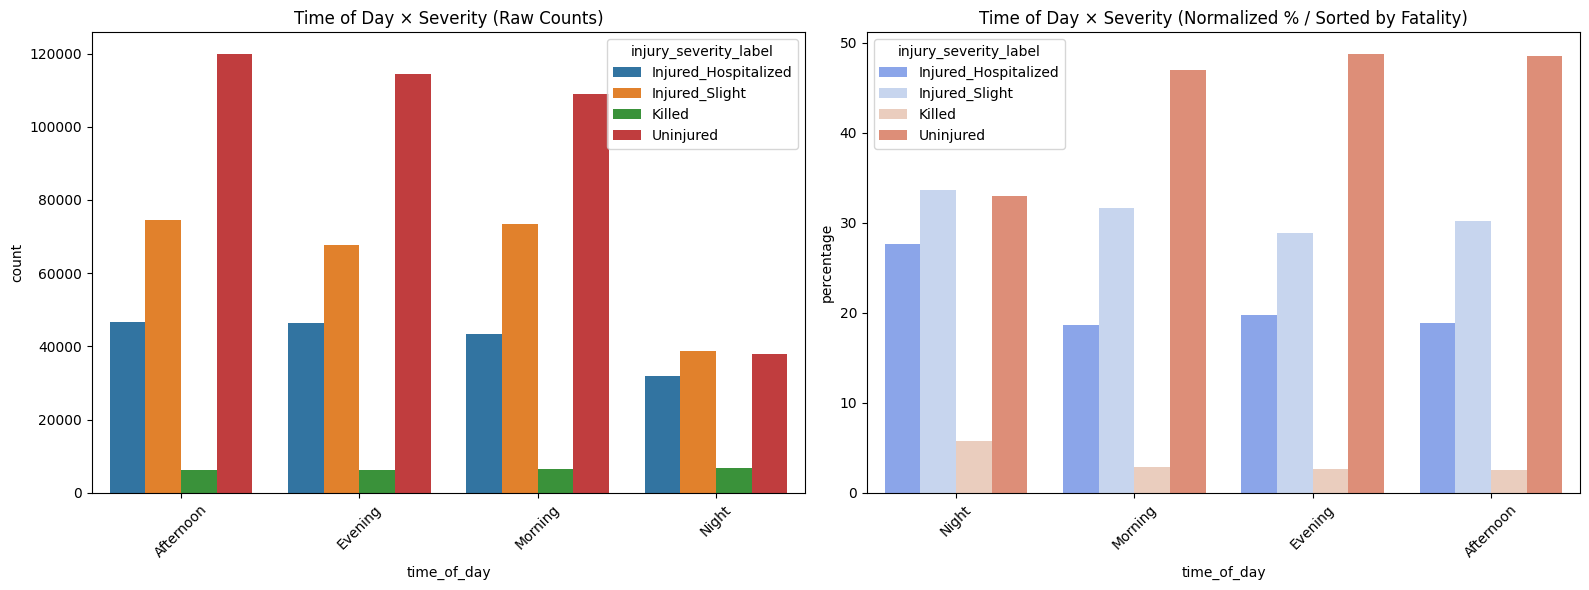

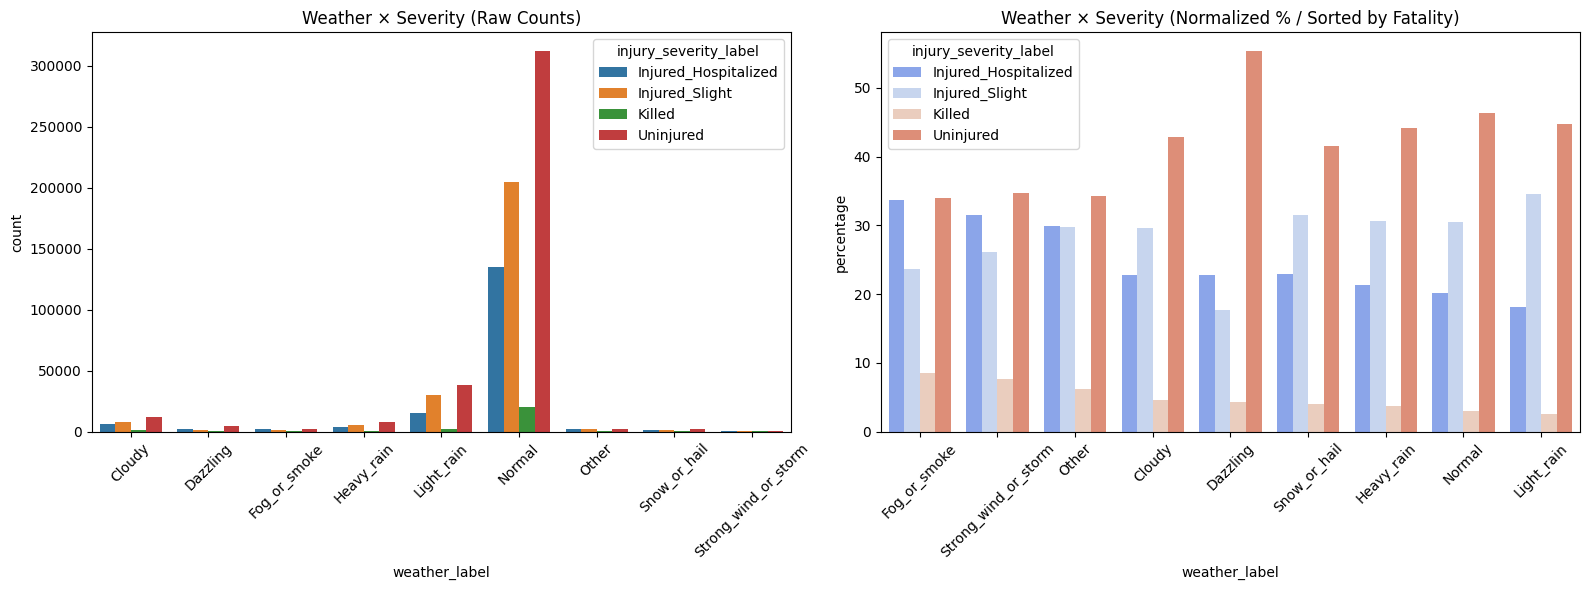

In [57]:
## 1 . Risk profiles by time and weather

# --- Time of Day ---
tod_raw = (
    acc_unique.groupby(["time_of_day","injury_severity_label"], observed=True)
              .size().reset_index(name="count")
)
tod_norm = tod_raw.copy()
tod_norm["percentage"] = tod_norm.groupby("time_of_day", observed=True)["count"].transform(lambda x: 100*x/x.sum())
tod_order = (
    tod_norm[tod_norm["injury_severity_label"]=="Killed"]
    .sort_values("percentage", ascending=False)["time_of_day"]
    .tolist()
)

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=tod_raw, x="time_of_day", y="count", hue="injury_severity_label", ax=axes[0])
axes[0].set_title("Time of Day × Severity (Raw Counts)")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=tod_norm, x="time_of_day", y="percentage", hue="injury_severity_label",
            order=tod_order, palette="coolwarm", ax=axes[1])
axes[1].set_title("Time of Day × Severity (Normalized % / Sorted by Fatality)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Weather ---
weather_raw = (
    acc_unique.groupby(["weather_label","injury_severity_label"], observed=True)
              .size().reset_index(name="count")
)
weather_norm = weather_raw.copy()
weather_norm["percentage"] = weather_norm.groupby("weather_label", observed=True)["count"].transform(lambda x: 100*x/x.sum())
weather_order = (
    weather_norm[weather_norm["injury_severity_label"]=="Killed"]
    .sort_values("percentage", ascending=False)["weather_label"]
    .tolist()
)

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=weather_raw, x="weather_label", y="count", hue="injury_severity_label", ax=axes[0])
axes[0].set_title("Weather × Severity (Raw Counts)")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=weather_norm, x="weather_label", y="percentage", hue="injury_severity_label",
            order=weather_order, palette="coolwarm", ax=axes[1])
axes[1].set_title("Weather × Severity (Normalized % / Sorted by Fatality)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()




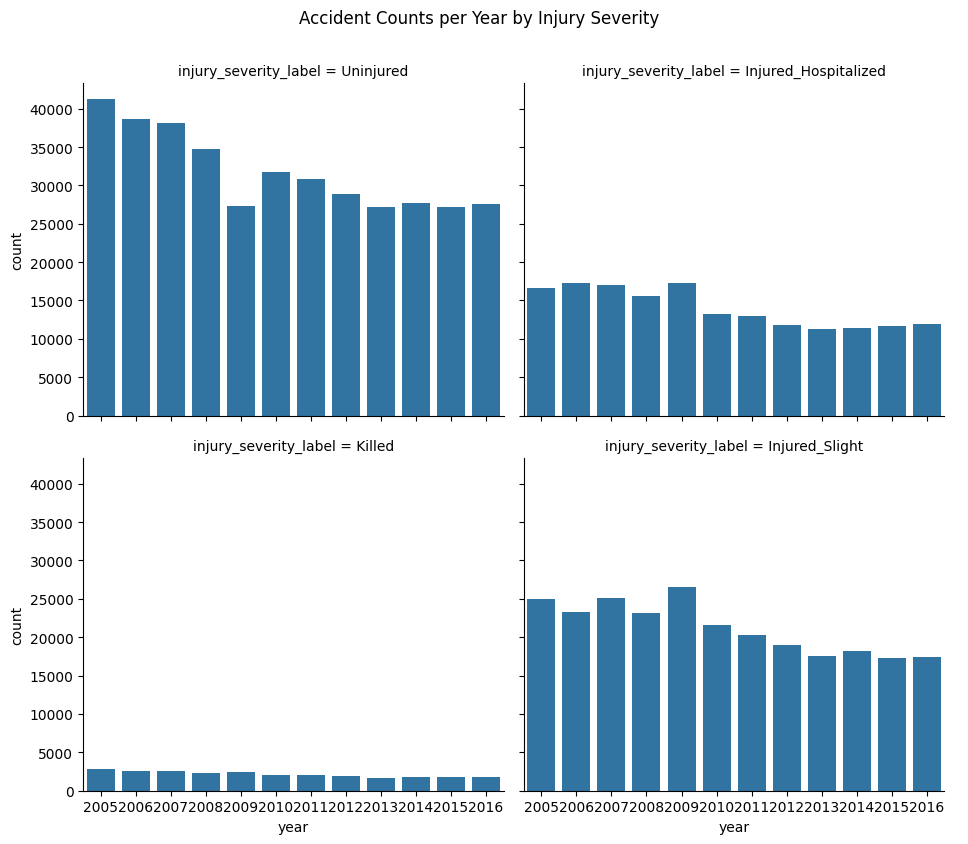

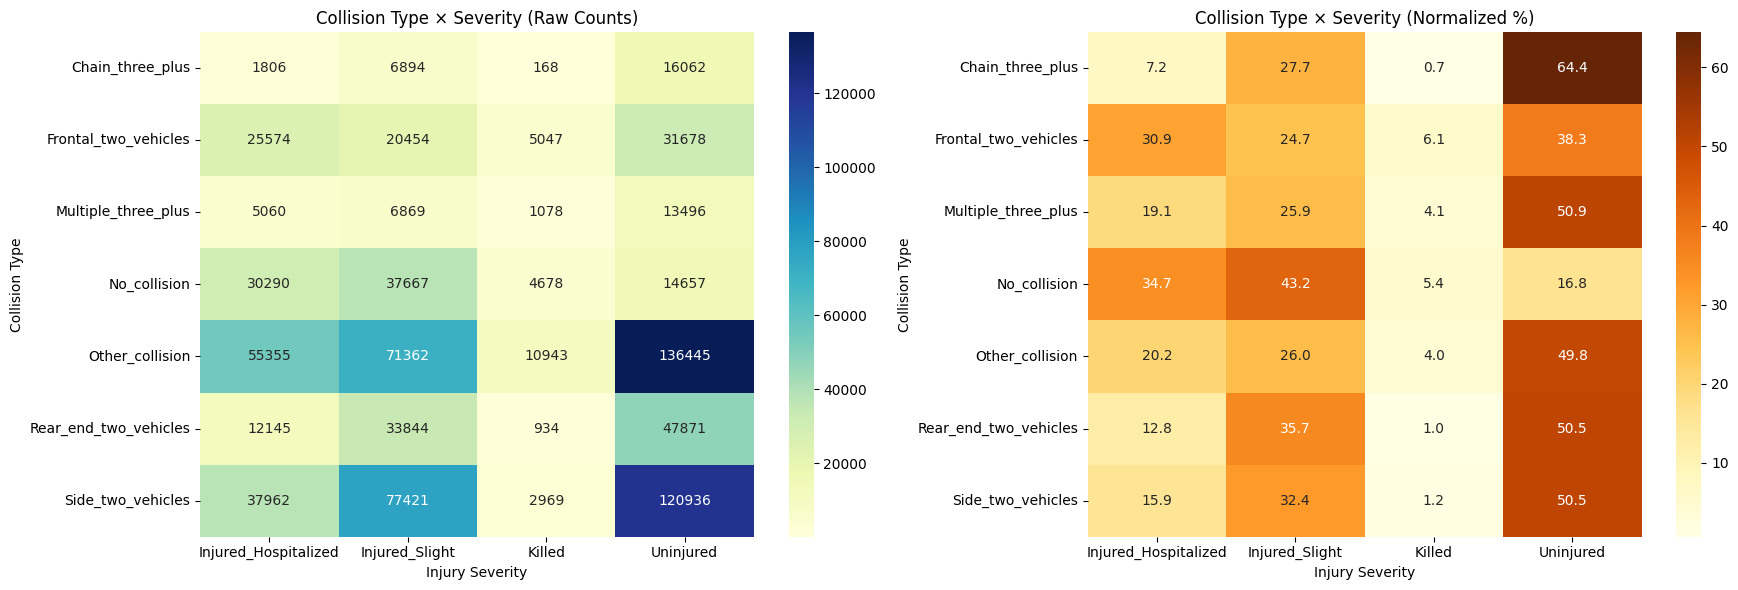

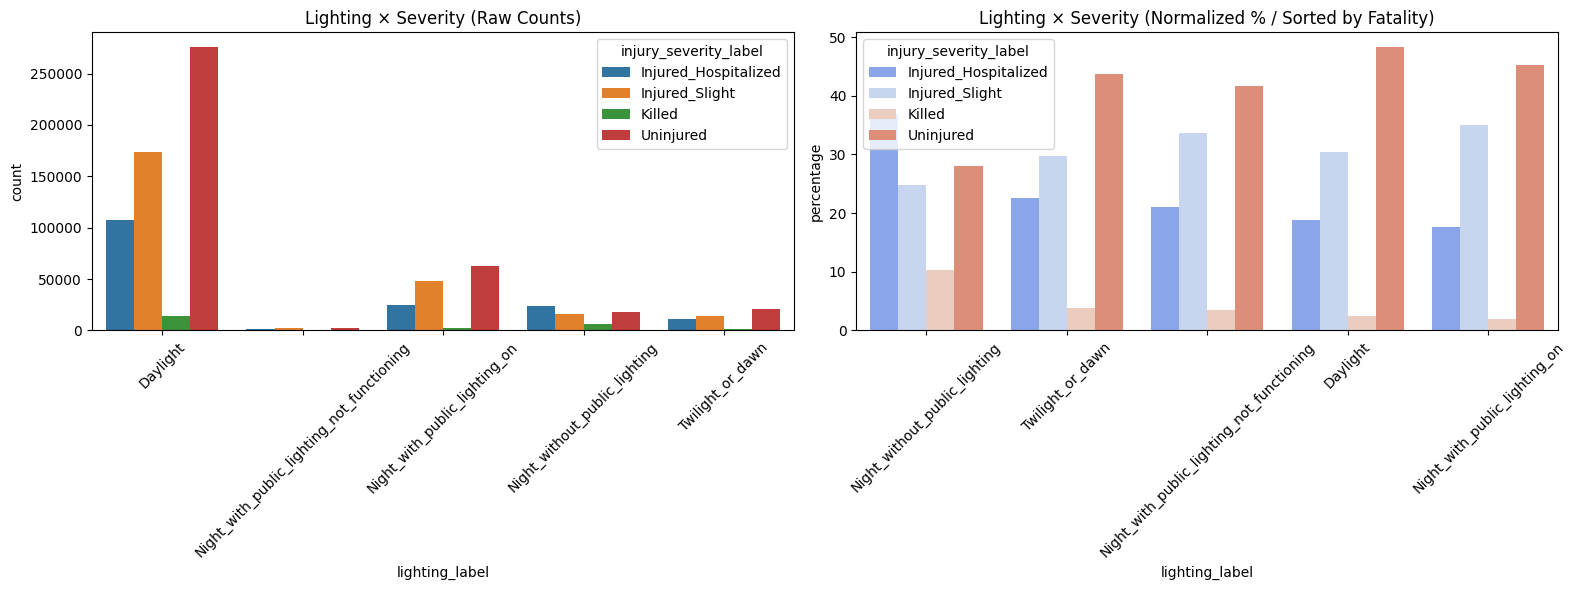

In [58]:
#Temporal Trends 
# --- 1. Facet bar plots: Accident counts per year, faceted by severity ---
facet = sns.catplot(
    data=acc_unique, kind="count",
    col="injury_severity_label", x="year",
    col_wrap=2, height=4, aspect=1.2
)

facet.fig.suptitle("Accident Counts per Year by Injury Severity", y=1.05)

# --- 2.  Collision Type × Injury Severity ---
collision_ct = pd.crosstab(acc_unique["collision_label"], acc_unique["injury_severity_label"])
collision_pct = collision_ct.div(collision_ct.sum(axis=1), axis=0) * 100

# --- Plot side by side ---
fig, axes = plt.subplots(1,2, figsize=(18,6))

# Raw Count Heatmap
sns.heatmap(collision_ct, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Collision Type × Severity (Raw Counts)")
axes[0].set_ylabel("Collision Type")
axes[0].set_xlabel("Injury Severity")

# Percentage Heatmap
sns.heatmap(collision_pct, annot=True, fmt=".1f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Collision Type × Severity (Normalized %)")
axes[1].set_ylabel("Collision Type")
axes[1].set_xlabel("Injury Severity")

plt.tight_layout()
plt.show()


# --- 3. Lighting ---
lighting_raw = (
    acc_unique.groupby(["lighting_label","injury_severity_label"], observed=True)
              .size().reset_index(name="count")
)
lighting_norm = lighting_raw.copy()
lighting_norm["percentage"] = lighting_norm.groupby("lighting_label", observed=True)["count"].transform(lambda x: 100*x/x.sum())
lighting_order = (
    lighting_norm[lighting_norm["injury_severity_label"]=="Killed"]
    .sort_values("percentage", ascending=False)["lighting_label"]
    .tolist()
)

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=lighting_raw, x="lighting_label", y="count", hue="injury_severity_label", ax=axes[0])
axes[0].set_title("Lighting × Severity (Raw Counts)")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=lighting_norm, x="lighting_label", y="percentage", hue="injury_severity_label",
            order=lighting_order, palette="coolwarm", ax=axes[1])
axes[1].set_title("Lighting × Severity (Normalized % / Sorted by Fatality)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

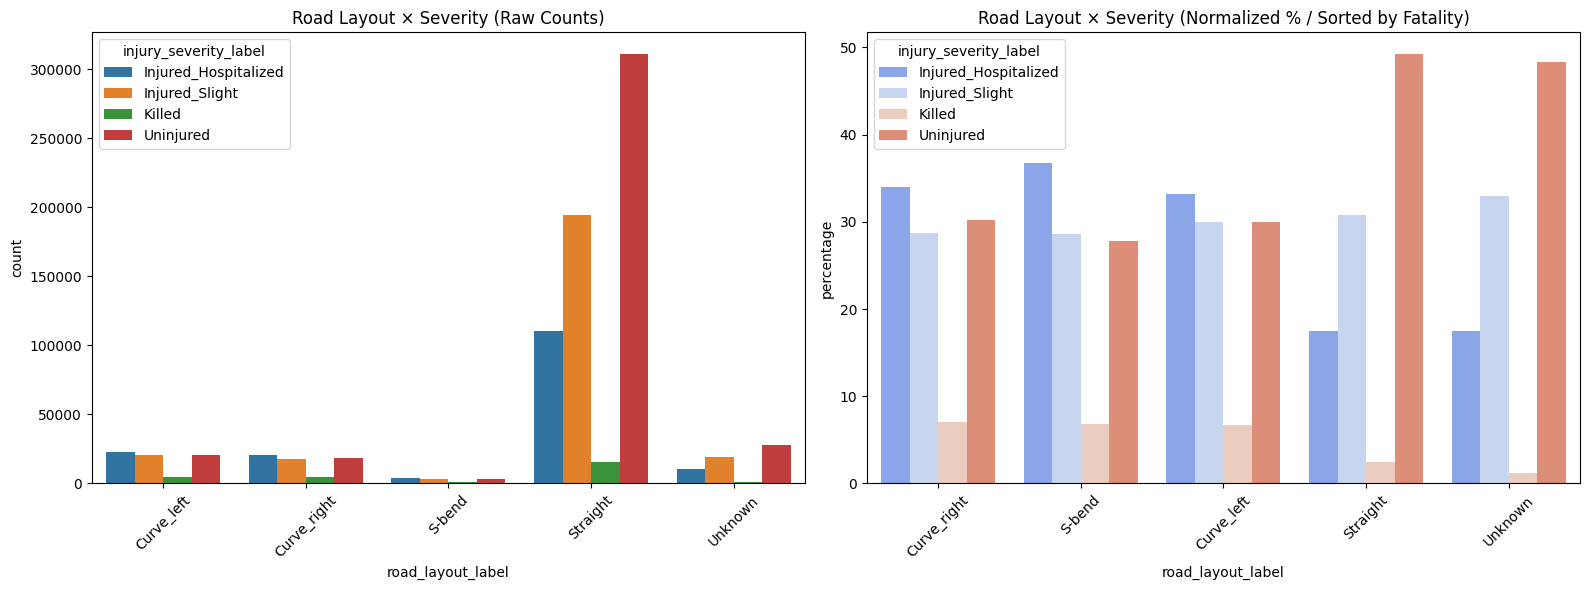

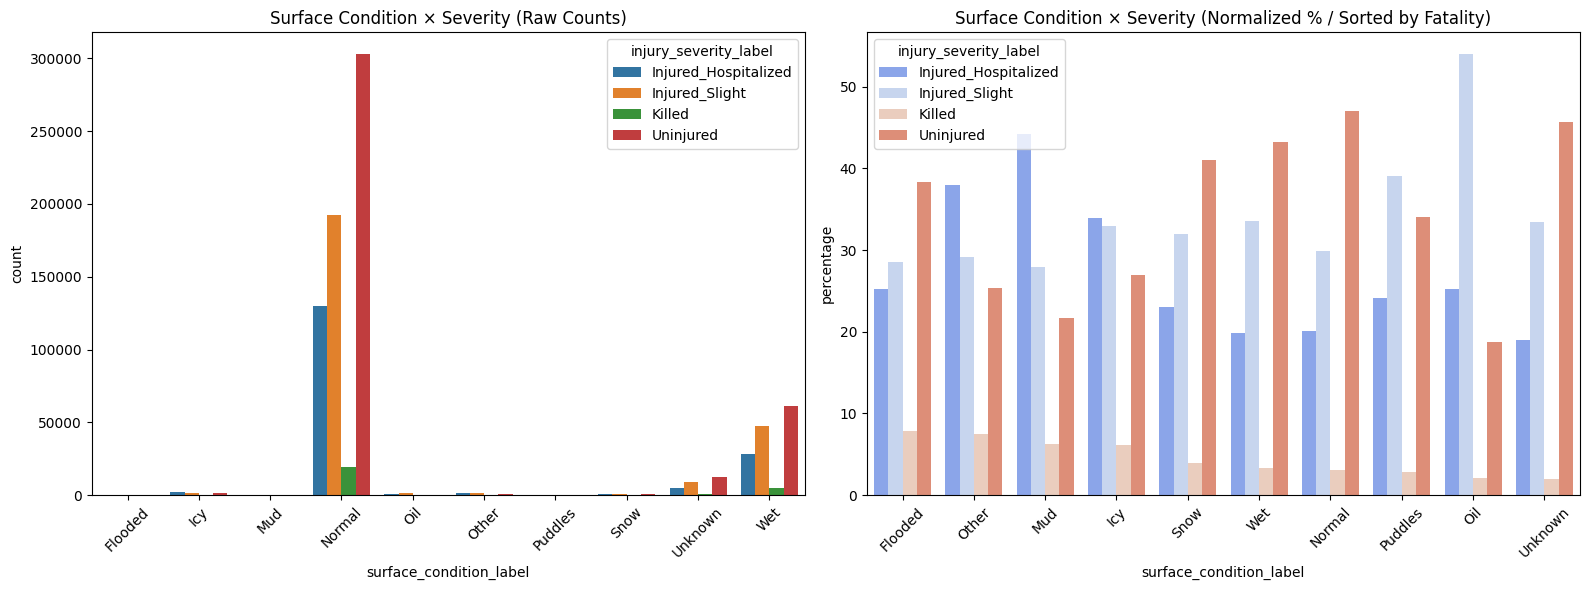

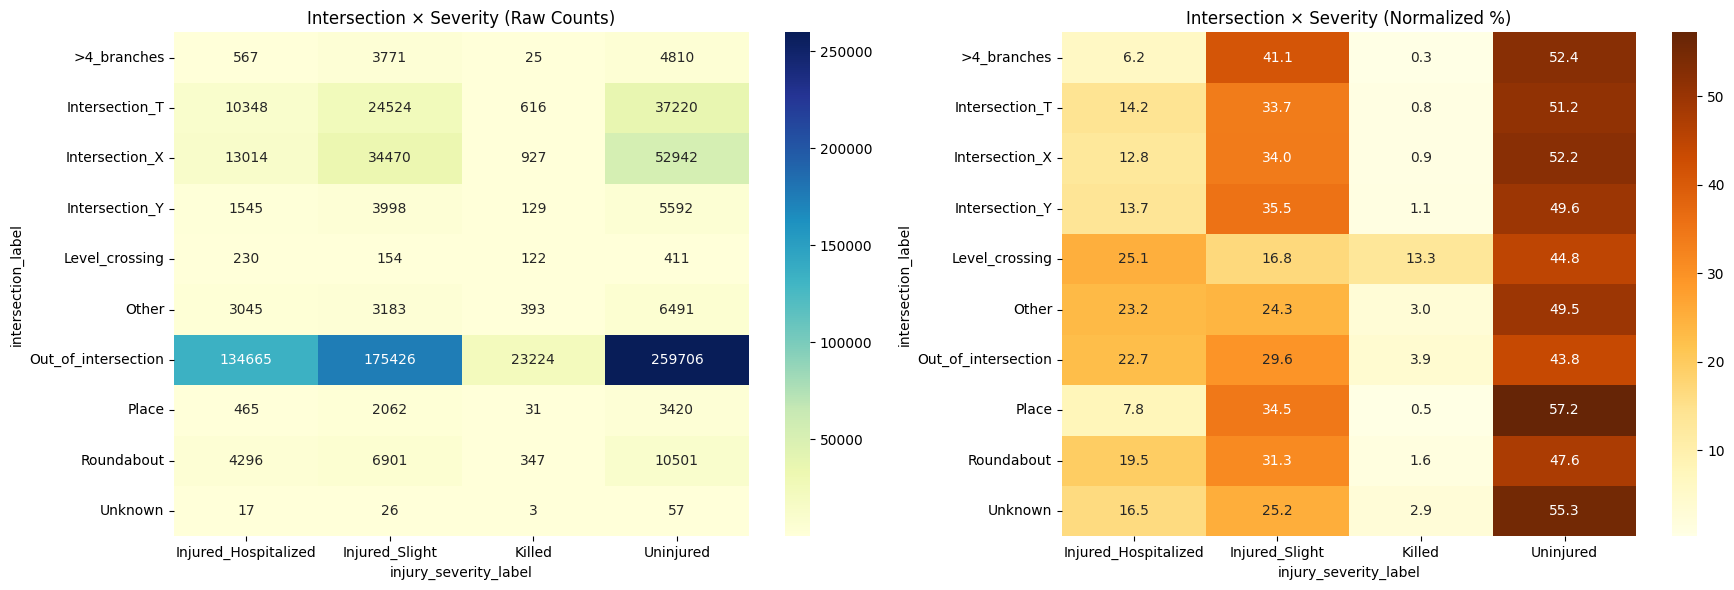

In [59]:
### Road & Infrastructure

# --- Road Layout ---
layout_raw = (
    acc_unique.groupby(["road_layout_label","injury_severity_label"], observed=True)
              .size().reset_index(name="count")
)
layout_norm = layout_raw.copy()
layout_norm["percentage"] = layout_norm.groupby("road_layout_label", observed=True)["count"].transform(lambda x: 100*x/x.sum())
fatality_order = (
    layout_norm[layout_norm["injury_severity_label"]=="Killed"]
    .sort_values("percentage", ascending=False)["road_layout_label"]
    .tolist()
)

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=layout_raw, x="road_layout_label", y="count", hue="injury_severity_label", ax=axes[0])
axes[0].set_title("Road Layout × Severity (Raw Counts)")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=layout_norm, x="road_layout_label", y="percentage", hue="injury_severity_label",
            order=fatality_order, palette="coolwarm", ax=axes[1])
axes[1].set_title("Road Layout × Severity (Normalized % / Sorted by Fatality)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Surface Condition ---
surface_raw = (
    acc_unique.groupby(["surface_condition_label","injury_severity_label"], observed=True)
              .size().reset_index(name="count")
)
surface_norm = surface_raw.copy()
surface_norm["percentage"] = surface_norm.groupby("surface_condition_label", observed=True)["count"].transform(lambda x: 100*x/x.sum())
surface_order = (
    surface_norm[surface_norm["injury_severity_label"]=="Killed"]
    .sort_values("percentage", ascending=False)["surface_condition_label"]
    .tolist()
)

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.barplot(data=surface_raw, x="surface_condition_label", y="count", hue="injury_severity_label", ax=axes[0])
axes[0].set_title("Surface Condition × Severity (Raw Counts)")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=surface_norm, x="surface_condition_label", y="percentage", hue="injury_severity_label",
            order=surface_order, palette="coolwarm", ax=axes[1])
axes[1].set_title("Surface Condition × Severity (Normalized % / Sorted by Fatality)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Intersection Heatmap ---
intersection_ct = pd.crosstab(acc_unique["intersection_label"], acc_unique["injury_severity_label"])
intersection_pct = intersection_ct.div(intersection_ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1,2, figsize=(18,6))
sns.heatmap(intersection_ct, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Intersection × Severity (Raw Counts)")

sns.heatmap(intersection_pct, annot=True, fmt=".1f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Intersection × Severity (Normalized %)")
plt.tight_layout()
plt.show()

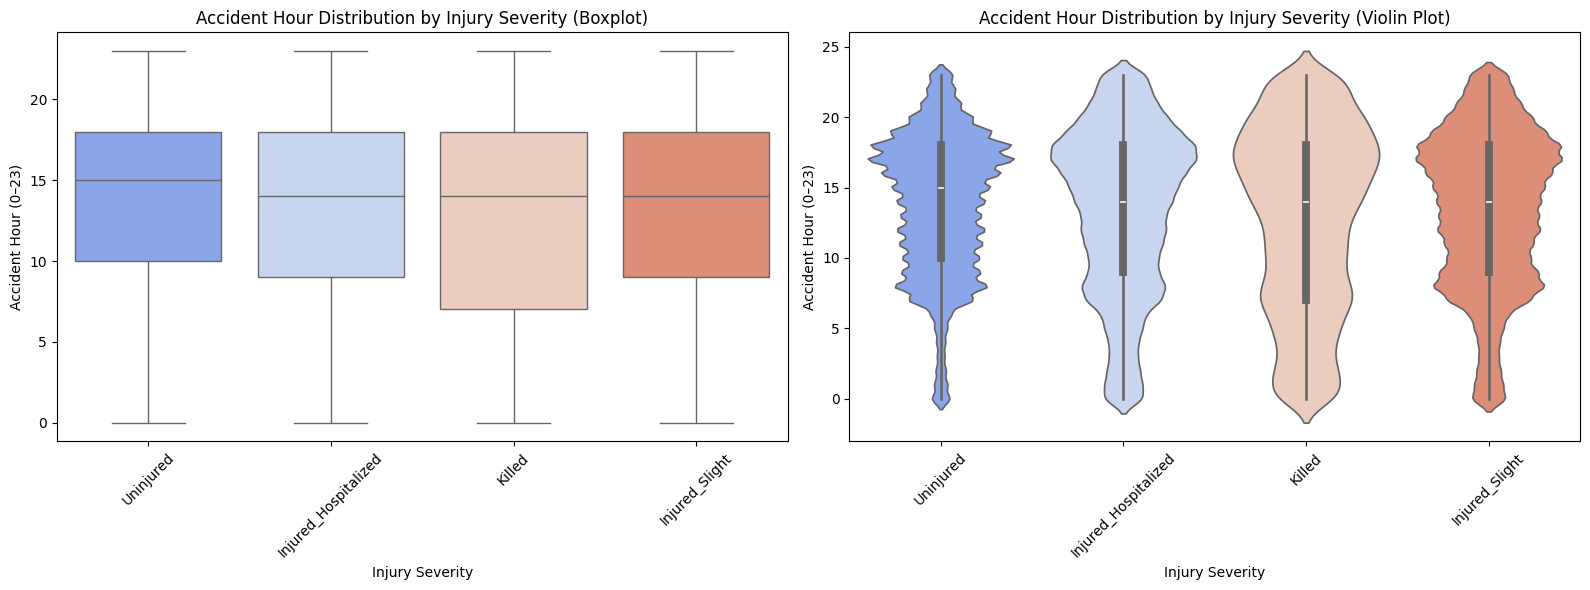

In [60]:
##Accident hour vs severity → distribution of accident times by severity

fig, axes = plt.subplots(1,2, figsize=(16,6))

# --- Boxplot ---
sns.boxplot(data=acc_unique, 
            x="injury_severity_label", 
            y="hour", 
            hue="injury_severity_label", 
            palette="coolwarm", 
            legend=False, ax=axes[0])
axes[0].set_title("Accident Hour Distribution by Injury Severity (Boxplot)")
axes[0].set_xlabel("Injury Severity")
axes[0].set_ylabel("Accident Hour (0–23)")
axes[0].tick_params(axis='x', rotation=45)

# --- Violin Plot ---
sns.violinplot(data=acc_unique, 
               x="injury_severity_label", 
               y="hour", 
               hue="injury_severity_label", 
               palette="coolwarm", 
               legend=False, ax=axes[1])
axes[1].set_title("Accident Hour Distribution by Injury Severity (Violin Plot)")
axes[1].set_xlabel("Injury Severity")
axes[1].set_ylabel("Accident Hour (0–23)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\malik\AppData\Local\Temp\ipykernel_14212\3939132561.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acc_unique.loc[:, "light_weather"] = acc_unique["lighting_label"].astype(str) + " | " + acc_unique["weather_label"].astype(str)


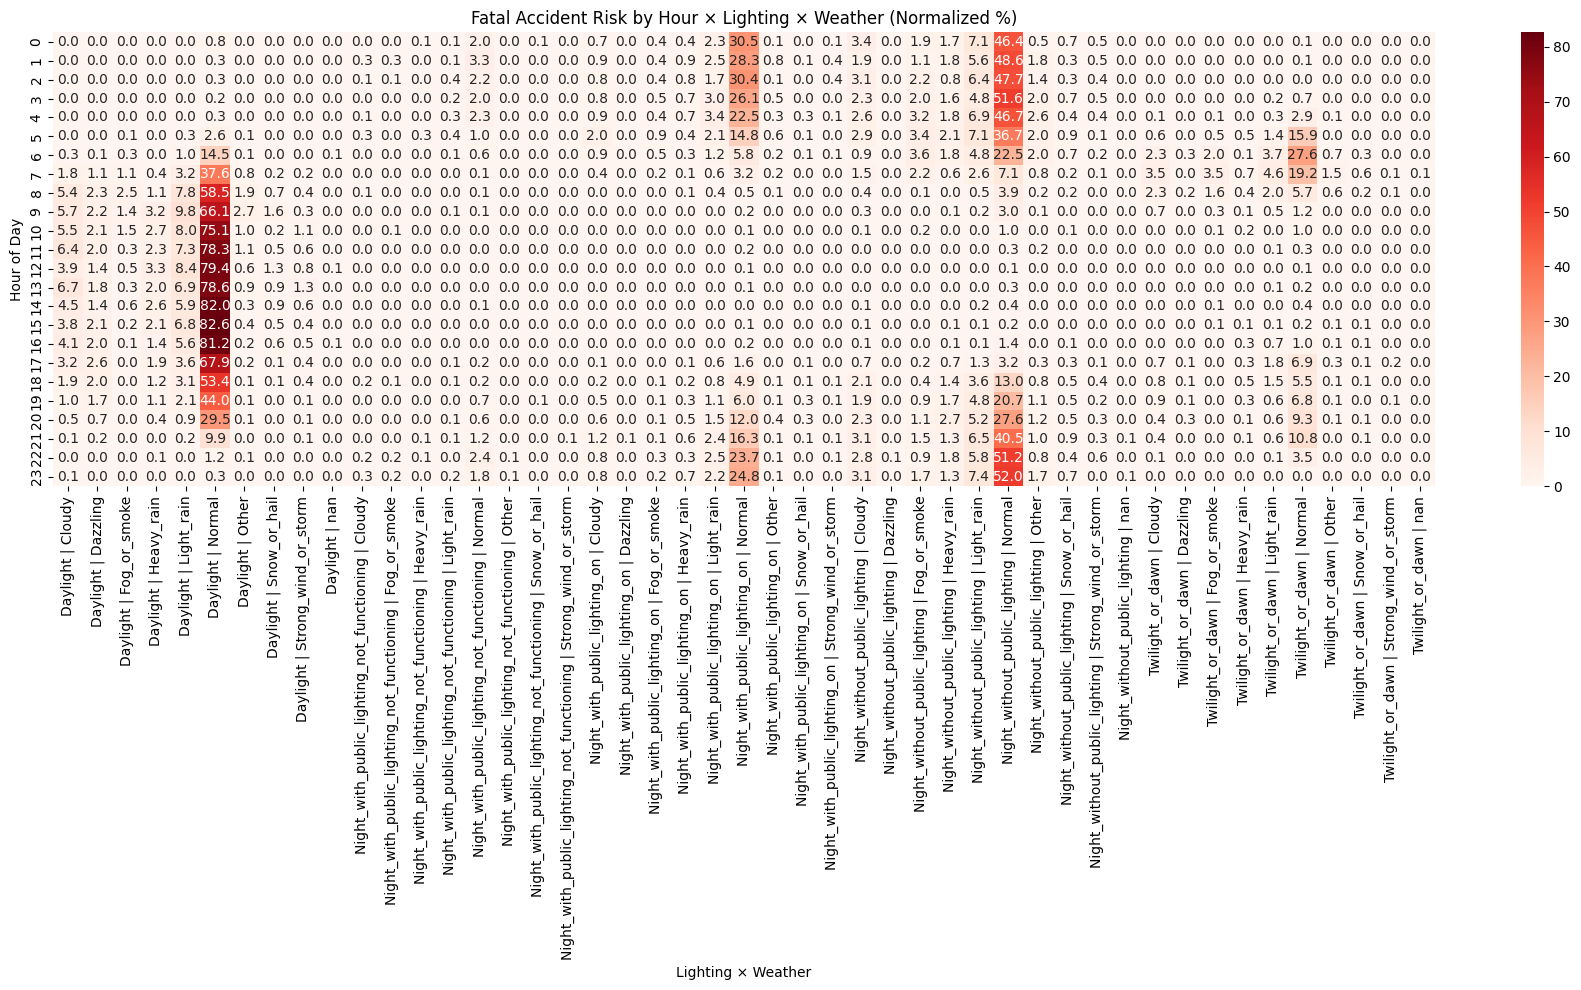

In [61]:
# fatal accident percentages by hour × lighting × weather

acc_unique.loc[:, "light_weather"] = acc_unique["lighting_label"].astype(str) + " | " + acc_unique["weather_label"].astype(str)

# Filter for fatal accidents
fatal_only = acc_unique[acc_unique["injury_severity_label"] == "Killed"]

# Group by hour and combined label
compound_risk = (
    fatal_only.groupby(["hour", "light_weather"], observed=True)
              .size()
              .reset_index(name="count")
)

# Normalize within each hour
compound_risk["percentage"] = compound_risk.groupby("hour", observed=True)["count"].transform(lambda x: 100 * x / x.sum())

# Pivot for heatmap
fatal_pivot = compound_risk.pivot(index="hour", columns="light_weather", values="percentage").fillna(0)

# Plot
plt.figure(figsize=(18,10))
sns.heatmap(fatal_pivot, cmap="Reds", annot=True, fmt=".1f")
plt.title("Fatal Accident Risk by Hour × Lighting × Weather (Normalized %)")
plt.xlabel("Lighting × Weather")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

In [62]:
### Exporting Master Data - ACC to csv

acc.to_csv("acc.csv", index=True, encoding="utf-8")